# Kernel benchmark analysis

Loads the per-kernel timing CSVs under `output/kernels/keys_<N>/` (one
self-describing CSV per kernel variant, one row per timed run) and provides
robust per-kernel summaries plus comparison plots.

**Structure:** the **PREP** cell builds every shared DataFrame once from
`data`. All plot cells below read only those names (`agg`, `summary`,
`winners`, `geo_win`, `seg`, `bins`, `key_counts`, style maps) and reassign
none of them — so they can be run or reordered freely once Load + PREP have
run. Each plot cell still owns its plot-local temporaries (pivots, best-of
selections).

**Note on variance:** the first several runs of some kernels show a gradual
DVFS clock ramp, so `mean` is biased low. We use the **median** as the robust
per-experiment statistic.

## Methodology

**Environment**
- Device: Apple **M2 Max** (Mac14,6), **macOS 26.5.1** (25F80).
- GPU API: WebGPU via **wgpu-native, Dawn backend** (release preset) → Metal.
  Dawn is required — the older wgpu Metal path returned zero GPU timestamps on
  macOS 26 / Metal 4.
- Memory bandwidth: ~**379.7 GB/s** measured (writeback kernel; published 400).
  Analysis uses **380 GB/s** → a **31.7 G keys/s** roofline at 12 B/key.

**What's sorted**
- Keys: **32-bit unsigned**, uniformly random.
- Payload: a parallel array of **32-bit value indices** (index sort);
  validation checks keys *and* value indices.
- Bandwidth model: **12 B/key** (read key + write key + write value index).

**Kernels under test** — a bitonic network with four cross-lane memory
strategies: **reg** (register/subgroup shuffle), **smem/wg** (shared-memory),
**hybrid** (subgroup below the warp width, smem across it), **hybmerge**
(subgroup register-runs merged via merge-path through smem; closest analog to
Hou et al's shared-memory kernel). Store layout: **block** (contiguous per
thread, uncoalesced) vs **striped** (coalesced, via a blocked→striped
transpose: shfl_xor butterfly for reg, smem for wg/hybrid, smem-staged for
hybmerge). Workgroup size is set per kernel at pipeline creation; kernels are
generated by `kernel_generator.py`.

**Workload**
- Bins: bin *b* spans segment sizes `(2^(b-1), 2^b]`; bins 1–11 → **N = 2…2048**.
- Sampler `const(1.0)`: every segment is exactly N (**uniform** segment sizes,
  no within-bin skew); ~`n_keys/N` segments per bin.
- Deterministic: **seed = 1**, fresh sampler per bin.
- Key counts: **12.4M, 102.4M, 268,435,456 (2^28)**.
- smem budgets: **16 KB** for all; **32 KB** added for the 60 high-WPT
  wg/hybrid configs where it changes workgroup size.

**Measurement protocol**
- Per condition: **5 warmup** iterations (unrecorded, full measured path) +
  **50 recorded runs**. Keys buffer reset from a pristine staging copy before
  each timed run.
- Timing: **`gpu_ns`** = Metal timestamp span of the compute pass (throughput =
  `keys/gpu_ns`); `wall_ns` = host submit→wait (not used — the CSV's
  `throughput_mkeys_s` is wall-based and is recomputed here from `gpu_ns`).
  Timestamps quantize at ~65 µs.
- Thermal control: before each experiment and every 5 runs, a Darwin
  thermal-pressure gate waits until pressure returns to nominal (poll 1 s,
  120 s cap; ~90 s typical when it fires). No fixed sleeps.

**Correctness** — every kernel is validated against a CPU segmented-sort
reference per bin (keys + value indices); all passed.

**Aggregation** — per-experiment value is the **median** of the 50 per-run GPU
throughputs; min→max shown as whiskers; CV = std/mean. The "robust winner"
maximizes the **geomean** of medians across key counts.

**Caveats** — 12.4M is noisiest (~400–490 µs fixed dispatch overhead is a
larger fraction there; CV up to ~20% vs ~0.5% at 268M). Uniform segments only.
`gpu_ns` is quantized (median used; min-time is the least-noisy alternative).
Timings cover the sort dispatch only (binning is a separate pass).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap, BoundaryNorm

pd.set_option("display.max_rows", 200)

# Shared family style (used by every plot below).
FAMILY_COLORS = {
    "reg": "#e8834a",       # register
    "smem": "#4269d0",      # workgroup / shared memory
    "hybrid": "#59a14f",    # subgroup hybrid
    "hybmerge": "#b07aa1",  # subgroup hybrid + merge
}
FAMILY_LABEL = {
    "reg": "register",
    "smem": "smem",
    "hybrid": "hybrid",
    "hybmerge": "hybmerge",
}
SG_COLORS = {8: "#4269d0", 16: "#e8834a", 32: "#59a14f"}

MEM_BW_GBPS = 380.0   # measured device memory bandwidth (writeback kernel)
BYTES_PER_KEY = 12    # 2x4 read/write key + 1x4 write value index
CEIL_GKEYS = MEM_BW_GBPS / BYTES_PER_KEY  # ceiling in G keys/s (~31.67)
WIN_BINS = [7, 8, 9]  # bins where hybrid beats hybmerge (highlight band)

## Load (raw per-run rows)

In [2]:
def load(root="../output/kernels") -> pd.DataFrame:
    """Concatenate every kernel CSV under root/keys_*/ into one tidy frame.

    One row per timed run. Adds `kernel`, `family`, `avg_seg`, `gpu_us`, and a
    GPU-timestamp throughput `gkeys_s`.
    """
    root = Path(root)
    frames = []
    for csv in sorted(root.glob("keys_*/*.csv")):
        if csv.name.endswith(".validation.csv"):   # skip the validation sidecar
            continue
        df = pd.read_csv(csv)
        if "throughput_mkeys_s" not in df.columns:
            continue
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"no kernel CSVs found under {root}/keys_*/")

    data = pd.concat(frames, ignore_index=True)
    data["kernel"] = data["root"].map(lambda p: Path(p).name)
    data["family"] = data["memory"]
    data["avg_seg"] = data["keys"] / data["segments"]
    data["gpu_us"] = data["gpu_ns"] / 1e3

    # The CSV's throughput_mkeys_s is WALL-based (host submit + wait, up to ~13%
    # overhead at small key counts). Use GPU-timestamp throughput instead:
    # keys / gpu_ns == G keys/s (1 key/ns = 1e9 keys/s = 1 G keys/s).
    data["wall_gkeys_s"] = data["throughput_mkeys_s"] / 1e3          # reference only
    data["gkeys_s"] = data["keys"] / data["gpu_ns"].replace(0, np.nan)
    return data


data = load()
print(f"{len(data):,} run-rows | "
      f"{data['kernel'].nunique()} kernels | "
      f"key counts: {sorted(data['n_keys'].unique())}")
data.head()

59,700 run-rows | 398 kernels | key counts: [np.int64(12400000), np.int64(102400000), np.int64(268435456)]


,root,memory,store,seed,runs,N,M,wpt,R,subgroups,...,run,wall_ns,gpu_ns,throughput_mkeys_s,kernel,family,avg_seg,gpu_us,wall_gkeys_s,gkeys_s
0,output/kernels/keys_102400000/segsort_hybmerge...,hybmerge,block,1,50,1024,128,8,16,16,...,0,28452000,27983872,3659.250585,segsort_hybmerge_sg16_smem16k_n1024_m128_block,hybmerge,1024.0,27983.872,3.599044,3.659251
1,output/kernels/keys_102400000/segsort_hybmerge...,hybmerge,block,1,50,1024,128,8,16,16,...,1,28080000,27721728,3693.853428,segsort_hybmerge_sg16_smem16k_n1024_m128_block,hybmerge,1024.0,27721.728,3.646724,3.693853
2,output/kernels/keys_102400000/segsort_hybmerge...,hybmerge,block,1,50,1024,128,8,16,16,...,2,28091000,27590656,3711.401425,segsort_hybmerge_sg16_smem16k_n1024_m128_block,hybmerge,1024.0,27590.656,3.645296,3.711401
3,output/kernels/keys_102400000/segsort_hybmerge...,hybmerge,block,1,50,1024,128,8,16,16,...,3,28399000,27852800,3676.470588,segsort_hybmerge_sg16_smem16k_n1024_m128_block,hybmerge,1024.0,27852.800,3.605761,3.676471
4,output/kernels/keys_102400000/segsort_hybmerge...,hybmerge,block,1,50,1024,128,8,16,16,...,4,27905000,27459584,3729.116945,segsort_hybmerge_sg16_smem16k_n1024_m128_block,hybmerge,1024.0,27459.584,3.669593,3.729117


## PREP — all shared DataFrames (built once)

`agg` is the workhorse: **one row per (kernel, key count)** with the median
throughput plus spread (min/max/mean/std/cv) and median GPU/wall times. Every
plot reads `agg` (and the derived tables below); none re-aggregate raw runs.

In [3]:
# --- per-experiment aggregate: one row per (kernel, key count) ---------------
_ID = ["memory", "store", "bin", "N", "M", "subgroups", "kernel", "n_keys"]
agg = (data.groupby(_ID, as_index=False)
           .agg(gkeys_s=("gkeys_s", "median"),   # the per-experiment value
                lo=("gkeys_s", "min"),
                hi=("gkeys_s", "max"),
                mean=("gkeys_s", "mean"),
                std=("gkeys_s", "std"),
                gpu_us=("gpu_us", "median"),
                wall_us=("wall_ns", "median")))
agg["family"] = agg["memory"]
agg["cv"] = 100 * agg["std"] / agg["mean"]
agg["wall_us"] = agg["wall_us"] / 1e3

# --- lookups shared by every plot -------------------------------------------
key_counts = sorted(agg["n_keys"].unique())
bins = sorted(agg["bin"].unique())
seg = {b: int(agg.loc[agg["bin"] == b, "N"].iloc[0]) for b in bins}   # bin -> N

# --- per-kernel summary table (display) -------------------------------------
summary = (agg.rename(columns={"gkeys_s": "thru_median", "lo": "thru_min",
                               "hi": "thru_max", "mean": "thru_mean",
                               "std": "thru_std", "cv": "cv_pct"})
              [["n_keys", "family", "store", "kernel", "N", "M",
                "thru_min", "thru_median", "thru_mean", "thru_max",
                "thru_std", "cv_pct"]]
              .sort_values(["n_keys", "thru_median"], ascending=[True, False]))

# --- per (bin, key count) winner + achievable best (for regret) -------------
winners = agg.loc[agg.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()].copy()
cell_best = agg.groupby(["bin", "n_keys"])["gkeys_s"].max()   # Series (bin,nk)->best

# --- robust (geomean-across-key-counts) winner per bin ----------------------
# only kernels present at every key count are eligible so the geomean compares.
_geo = (agg.groupby(["bin", "kernel"])
           .agg(geomean=("gkeys_s", lambda s: float(np.exp(np.log(s).mean()))),
                _n=("gkeys_s", "count"),
                family=("family", "first"))
           .reset_index())
_geo = _geo[_geo["_n"] == len(key_counts)]
geo_win = (_geo.loc[_geo.groupby("bin")["geomean"].idxmax()]
               .set_index("bin")[["kernel", "geomean", "family"]])

print(f"agg: {len(agg)} experiments (kernel x key count) | "
      f"{len(bins)} bins | key counts {key_counts}")
summary.head(20)

,n_keys,family,store,kernel,N,M,thru_min,thru_median,thru_mean,thru_max,thru_std,n_runs,cv_pct
240,12400000,reg,block,segsort_reg_n16_m16_block,16,16,18920.898438,27029.854911,27088.419596,31534.830729,3633.018642,50,13.411704
241,12400000,reg,block,segsort_reg_n16_m8_block,16,8,17200.816761,27029.854911,28506.121835,37841.796875,5644.248041,50,19.800126
273,12400000,reg,striped,segsort_reg_n32_m16_striped,32,16,8600.408381,27029.854911,24356.356534,27029.854911,4898.401985,50,20.111391
276,12400000,reg,striped,segsort_reg_n4_m4_striped,4,4,11129.940257,23651.123047,23053.816253,31534.830729,5544.805199,50,24.051572
257,12400000,reg,block,segsort_reg_n64_m32_block,64,32,21023.220486,21023.220486,21338.568793,23651.123047,862.637194,50,4.042620
315,12400000,smem,block,segsort_wg_n32_m16_block,32,16,13514.927455,21023.220486,19892.828593,23651.123047,2954.214647,50,14.850651
259,12400000,reg,block,segsort_reg_n8_m8_block,8,8,11129.940257,19972.059462,17934.386874,27029.854911,5051.209765,50,28.164943
123,12400000,hybrid,block,segsort_hybrid_sg16_n64_m32_block,64,32,18920.898438,18920.898438,19930.013021,21023.220486,1060.983177,50,5.323545
189,12400000,hybrid,striped,segsort_hybrid_sg16_n64_m32_striped,64,32,18920.898438,18920.898438,19509.548611,21023.220486,953.523654,50,4.887472
233,12400000,hybrid,striped,segsort_hybrid_sg8_n64_m32_striped,64,32,17200.816761,18920.898438,18817.693537,18920.898438,412.644046,50,2.192851


## Winning kernel per bin

One bar per bin (the winner), colored by family and labeled with the kernel,
with min→max whiskers. Two bases: the **per-size winner** (best median at this
key count) and the **geomean winner** (best geomean across all key counts).

,bin,N,family,kernel,med,lo,hi
0,1,2,reg,segsort_reg_n2_m2_striped,21.113402,21.005128,21.333333
1,2,4,reg,segsort_reg_n4_m4_striped,25.600000,25.283951,25.924051
2,3,8,reg,segsort_reg_n8_m8_block,27.675676,26.947368,27.863946
3,4,16,reg,segsort_reg_n16_m16_block,28.643357,28.444444,28.845070
4,5,32,reg,segsort_reg_n32_m16_striped,24.094118,23.953216,24.236686
5,6,64,reg,segsort_reg_n64_m32_block,19.140187,18.618182,19.230047
6,7,128,hybrid,segsort_hybrid_sg32_n128_m64_block,14.075601,14.027397,14.124138
7,8,256,hybmerge,segsort_hybmerge_sg16_smem16k_n256_m64_striped,10.864721,10.807388,10.893617
8,9,512,hybrid,segsort_hybrid_sg8_n512_m256_block,8.445361,8.359184,8.462810
9,10,1024,hybmerge,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,6.177979,6.095238,6.187311


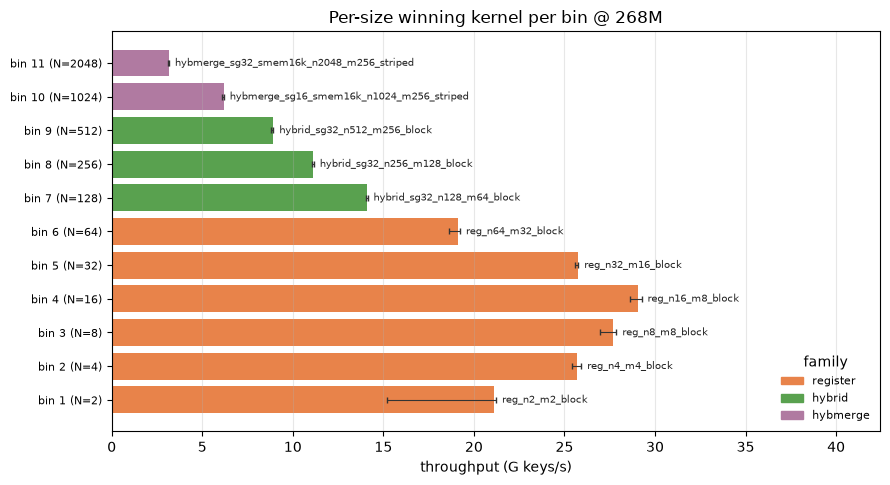

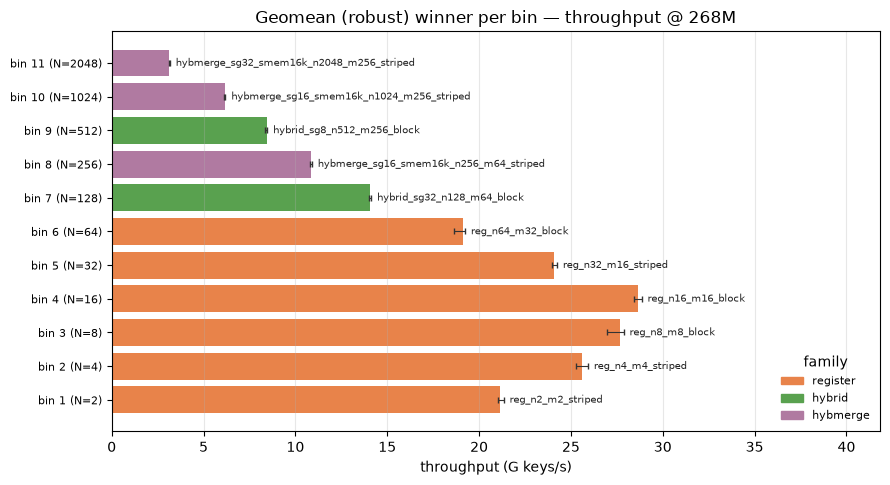

In [4]:
def plot_winners_bar(agg, n_keys, basis="winner"):
    sub = agg[agg["n_keys"] == n_keys]
    if basis == "geomean":
        gw = geo_win.reset_index()[["bin", "kernel"]]
        sel = sub.merge(gw, on=["bin", "kernel"])
        title = f"Geomean (robust) winner per bin — throughput @ {n_keys // 10**6}M"
    else:
        sel = sub.loc[sub.groupby("bin")["gkeys_s"].idxmax()]
        title = f"Per-size winning kernel per bin @ {n_keys // 10**6}M"
    sel = sel.sort_values("N")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(sel))))
    y = np.arange(len(sel))
    ax.barh(y, sel["gkeys_s"],
            color=[FAMILY_COLORS.get(f, "#888") for f in sel["family"]])
    ax.errorbar(sel["gkeys_s"], y,
                xerr=[sel["gkeys_s"] - sel["lo"], sel["hi"] - sel["gkeys_s"]],
                fmt="none", ecolor="#333", elinewidth=0.8, capsize=2)
    ax.set_yticks(y)
    ax.set_yticklabels([f"bin {int(b)} (N={int(n)})"
                        for b, n in zip(sel["bin"], sel["N"])], fontsize=8)
    for yi, (_, row) in zip(y, sel.iterrows()):
        ax.text(row["hi"], yi, "  " + row["kernel"].replace("segsort_", ""),
                va="center", ha="left", fontsize=7, color="#222")
    ax.set_xlabel("throughput (G keys/s)")
    ax.set_title(title)
    ax.set_xlim(0, sel["hi"].max() * 1.45)
    ax.grid(axis="x", alpha=0.3)
    handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f])
               for f in FAMILY_COLORS if f in set(sel["family"])]
    labs = [FAMILY_LABEL[f] for f in FAMILY_COLORS if f in set(sel["family"])]
    ax.legend(handles, labs, frameon=False, fontsize=8, title="family", loc="lower right")
    fig.tight_layout()
    return sel


plot_winners_bar(agg, n_keys=max(key_counts), basis="winner")
plot_winners_bar(agg, n_keys=max(key_counts), basis="geomean")

## Throughput vs key count, one plot per bin

Each bin (fixed segment size N) gets its own plot: every kernel is a line
(n_keys on x, G keys/s on y), colored by family. Solid bold = the 268M winner;
dashed bold = the geomean (robust) winner (labeled only when it differs). The
dashed horizontal line is the 31.7 G keys/s ceiling when it's in range.

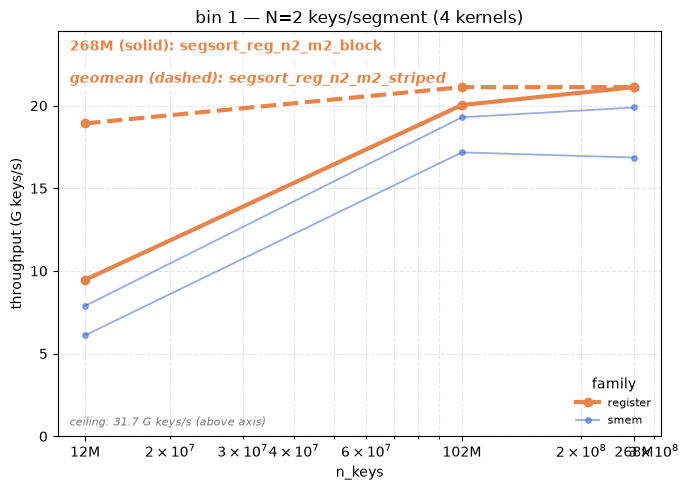

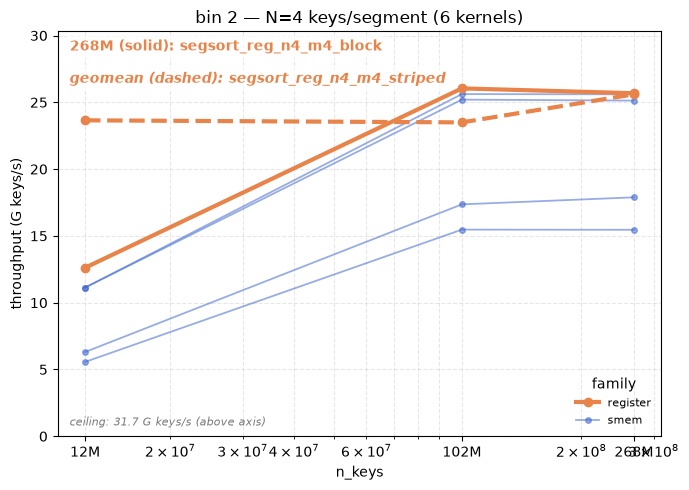

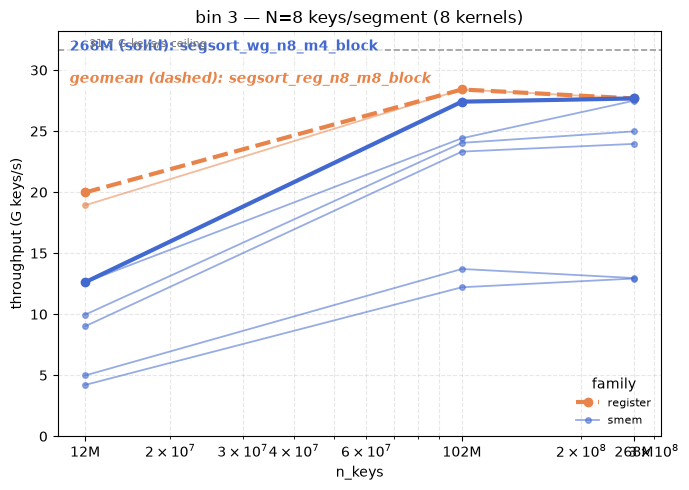

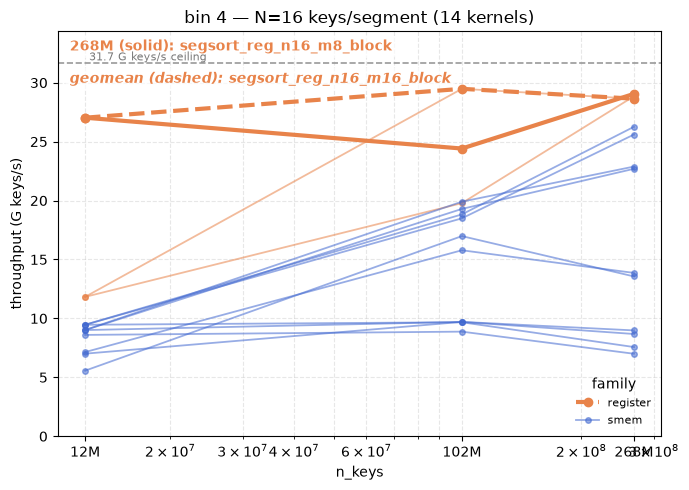

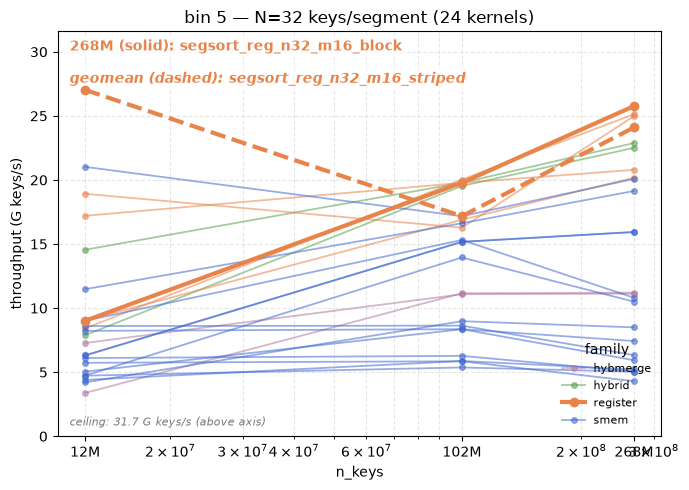

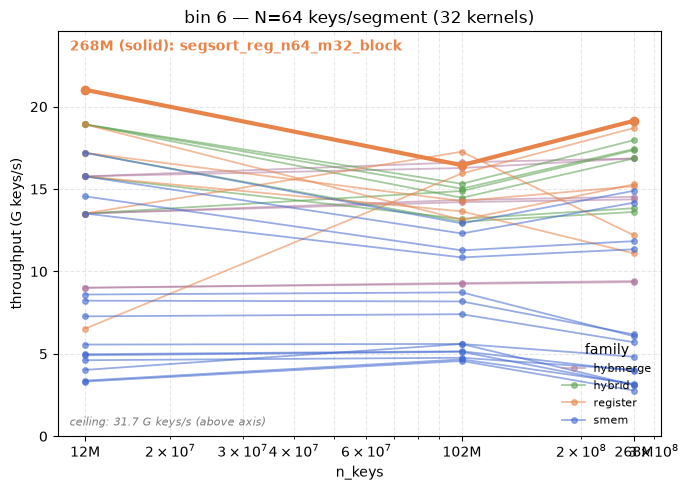

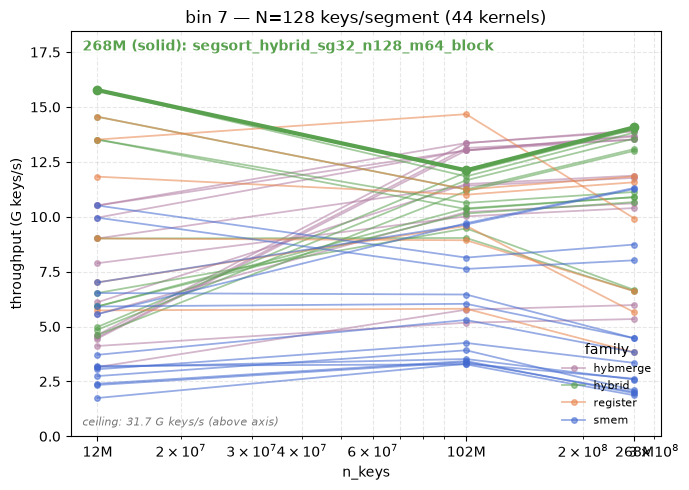

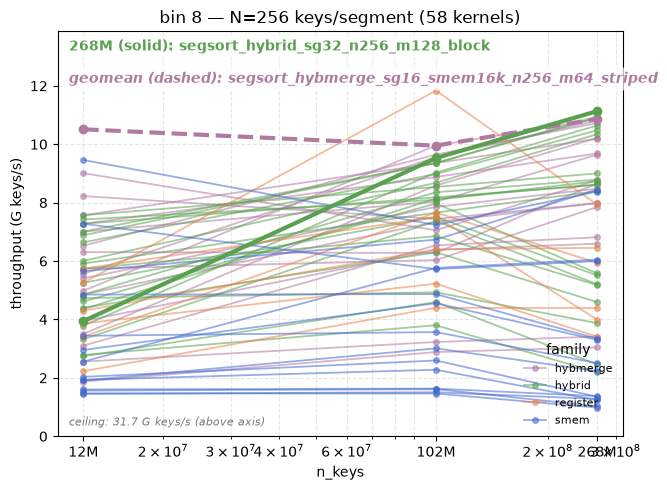

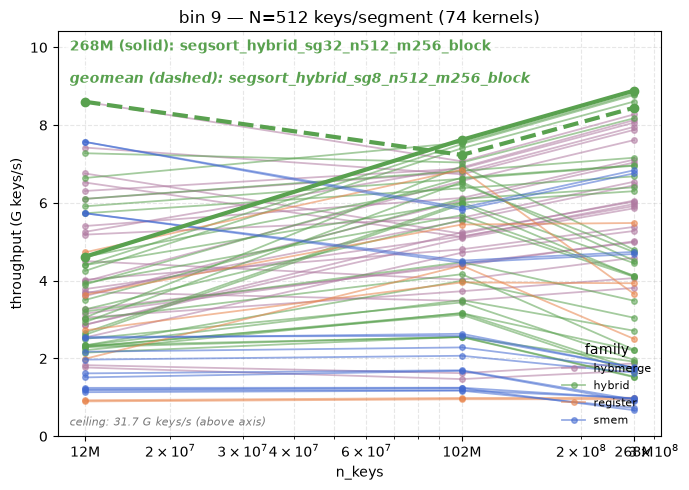

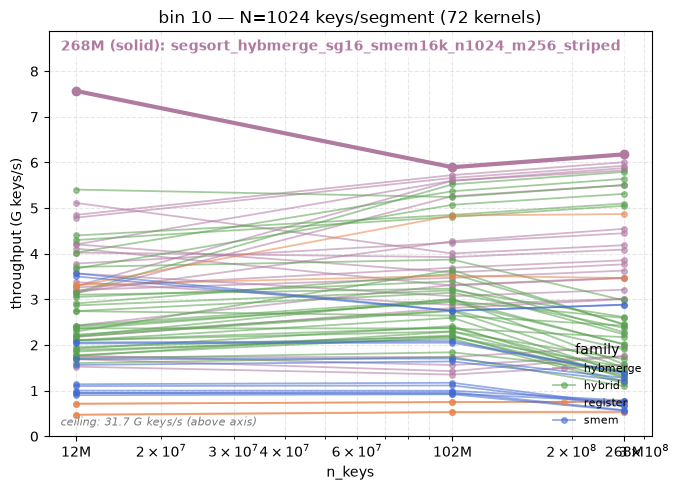

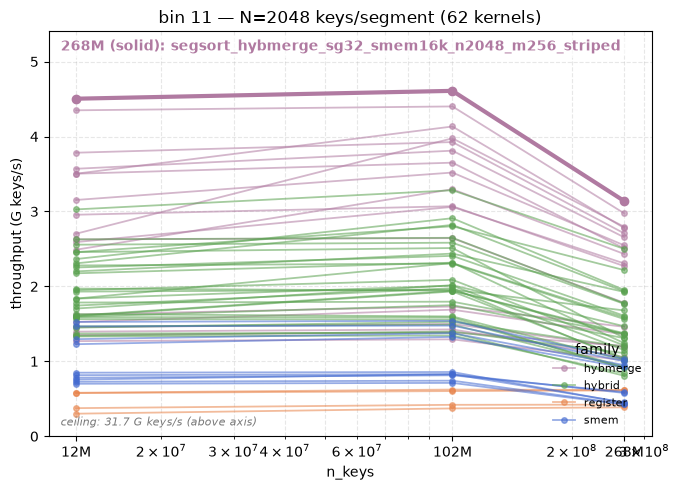

In [5]:
def plot_bin(agg, bin_id, ax=None):
    g = (agg[agg["bin"] == bin_id][["family", "kernel", "n_keys", "gkeys_s"]]
         .sort_values("n_keys"))
    if g.empty:
        raise ValueError(f"no data for bin {bin_id}")
    seg_n = seg[bin_id]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ref_nk = g["n_keys"].max()
    ref = g[g["n_keys"] == ref_nk]
    max_kernel = ref.loc[ref["gkeys_s"].idxmax(), "kernel"]
    geo_kernel = geo_win.loc[bin_id, "kernel"] if bin_id in geo_win.index else None

    def fam_of(kernel):
        return g.loc[g["kernel"] == kernel, "family"].iloc[0]

    seen = set()
    for (family, kernel), k in g.groupby(["family", "kernel"]):
        is_max = kernel == max_kernel
        is_geo = kernel == geo_kernel
        hi = is_max or is_geo
        ax.plot(
            k["n_keys"], k["gkeys_s"],
            marker="o", markersize=6 if hi else 4,
            linewidth=3.0 if hi else 1.3,
            linestyle="--" if (is_geo and not is_max) else "-",
            alpha=1.0 if hi else 0.55,
            zorder=6 if is_max else (5 if is_geo else 2),
            color=FAMILY_COLORS.get(family, "#888"),
            label=FAMILY_LABEL.get(family, family) if family not in seen else None,
        )
        seen.add(family)

    ax.text(0.02, 0.98, f"268M (solid): {max_kernel}", transform=ax.transAxes,
            ha="left", va="top", fontsize=10, fontweight="bold",
            color=FAMILY_COLORS.get(fam_of(max_kernel), "#333"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))
    if geo_kernel is not None and geo_kernel != max_kernel:
        ax.text(0.02, 0.90, f"geomean (dashed): {geo_kernel}",
                transform=ax.transAxes, ha="left", va="top", fontsize=10,
                fontweight="bold", fontstyle="italic",
                color=FAMILY_COLORS.get(fam_of(geo_kernel), "#333"),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))

    ax.set_ylim(bottom=0)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)   # headroom
    top = ax.get_ylim()[1]
    if CEIL_GKEYS <= top:
        ax.axhline(CEIL_GKEYS, color="#999", linestyle="--", linewidth=1.2)
        ax.text(g["n_keys"].min(), CEIL_GKEYS, f" {CEIL_GKEYS:.1f} G keys/s ceiling",
                va="bottom", ha="left", fontsize=8, color="#777")
    else:
        ax.text(0.02, 0.02, f"ceiling: {CEIL_GKEYS:.1f} G keys/s (above axis)",
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=8, color="#777", style="italic")

    ax.set_xscale("log")
    ax.set_xticks(sorted(g["n_keys"].unique()))
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1e6)}M"))
    ax.set_xlabel("n_keys")
    ax.set_ylabel("throughput (G keys/s)")
    ax.set_title(f"bin {bin_id} — N={seg_n} keys/segment "
                 f"({g['kernel'].nunique()} kernels)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, fontsize=8, title="family", loc="lower right")
    return ax


for _bin in bins:
    plot_bin(agg, _bin)
    plt.tight_layout()
    plt.show()

### Winner per bin (table)

In [6]:
def bin_winners(agg):
    ref = winners[winners["n_keys"] == max(key_counts)].sort_values("bin")
    out = (ref[["bin", "kernel", "gkeys_s"]]
           .rename(columns={"kernel": "winner", "gkeys_s": "throughput_gkeys_s"}))
    out["throughput_gkeys_s"] = out["throughput_gkeys_s"].round(2)
    return out.reset_index(drop=True)


bin_winners(agg)

,bin,winner,throughput_gkeys_s
0,1,segsort_reg_n2_m2_block,21.11
1,2,segsort_reg_n4_m4_block,25.68
2,3,segsort_reg_n8_m8_block,27.68
3,4,segsort_reg_n16_m8_block,29.05
4,5,segsort_reg_n32_m16_block,25.76
5,6,segsort_reg_n64_m32_block,19.14
6,7,segsort_hybrid_sg32_n128_m64_block,14.08
7,8,segsort_hybrid_sg32_n256_m128_block,11.13
8,9,segsort_hybrid_sg32_n512_m256_block,8.89
9,10,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,6.18


## Finding: hybrid beats hybmerge in bins 7–9

Best kernel of each family at the largest key count; **hybrid** overtakes
**hybmerge** in bins 7, 8, 9 (N=128/256/512). Top: paired throughput; bottom:
hybrid/hybmerge speedup ratio (bars above 1.0 = hybrid wins).

family,hybmerge,hybrid,ratio
bin,,,
5,11.206587,22.882682,2.041896
6,16.855967,17.964912,1.065789
7,13.931973,14.075601,1.010309
8,10.864721,11.130435,1.024457
9,8.274747,8.885033,1.073753
10,6.177979,5.793494,0.937765
11,3.138697,2.500611,0.796703


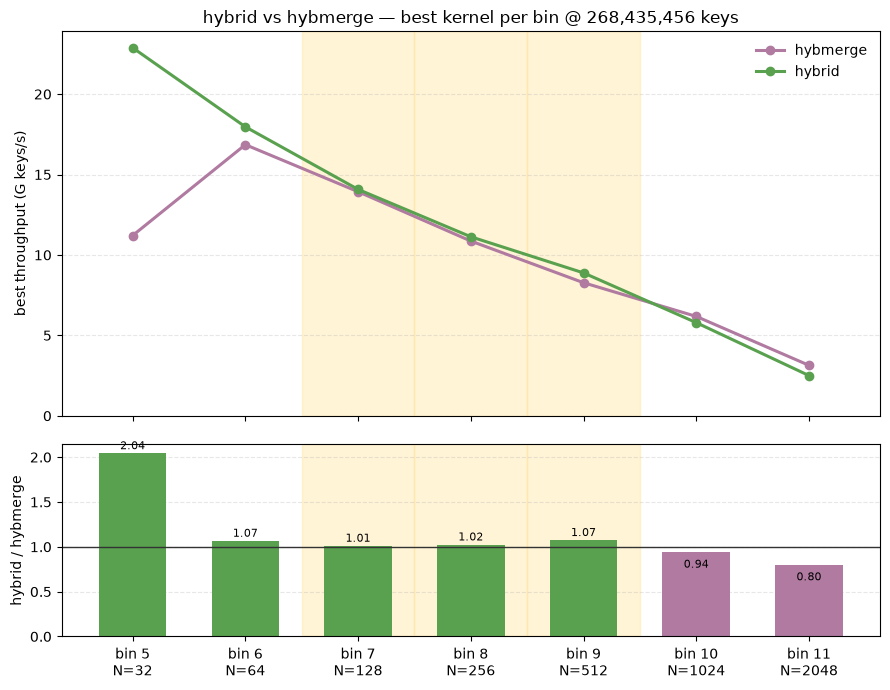

In [7]:
def hybrid_vs_hybmerge(agg):
    ref_nk = max(key_counts)
    sub = agg[(agg["family"].isin(["hybrid", "hybmerge"])) & (agg["n_keys"] == ref_nk)]
    best = sub.groupby(["bin", "family"])["gkeys_s"].max().unstack("family")
    both = best.dropna(subset=["hybrid", "hybmerge"]).sort_index()
    both["ratio"] = both["hybrid"] / both["hybmerge"]

    idx = list(both.index)
    x = np.arange(len(idx))
    labels = [f"bin {b}\nN={seg[b]}" for b in idx]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    for ax in (ax1, ax2):
        for b in WIN_BINS:
            if b in idx:
                i = idx.index(b)
                ax.axvspan(i - 0.5, i + 0.5, color="#ffe08a", alpha=0.35, zorder=0)

    for fam in ("hybmerge", "hybrid"):
        ax1.plot(x, both[fam], marker="o", markersize=6, linewidth=2.2,
                 color=FAMILY_COLORS[fam], label=FAMILY_LABEL[fam])
    ax1.set_ylabel("best throughput (G keys/s)")
    ax1.set_ylim(bottom=0)
    ax1.set_title(f"hybrid vs hybmerge — best kernel per bin @ {ref_nk:,} keys")
    ax1.legend(frameon=False, loc="upper right")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.3)

    colors = ["#59a14f" if r >= 1 else "#b07aa1" for r in both["ratio"]]
    ax2.bar(x, both["ratio"], width=0.6, color=colors, zorder=2)
    ax2.axhline(1.0, color="#333", linewidth=1)
    for xi, r in zip(x, both["ratio"]):
        ax2.annotate(f"{r:.2f}", (xi, r), textcoords="offset points",
                     xytext=(0, 3 if r >= 1 else -11), ha="center", fontsize=8)
    ax2.set_ylabel("hybrid / hybmerge")
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.grid(True, axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return both


hybrid_vs_hybmerge(agg)

## Subgroup size comparison (sg8 vs sg16 vs sg32)

Best kernel per bin for each subgroup size at the largest key count, for the
subgroup families. Lines start where each size first appears.

subgroups,8,16,32
bin,,,
5,22.882682,NaN,NaN
6,17.355932,17.964912,NaN
7,13.086262,13.837838,14.075601
8,10.475703,10.908142,11.130435
9,8.445361,8.770878,8.885033
10,5.100872,5.505376,5.793494
11,1.926170,1.773928,2.500611


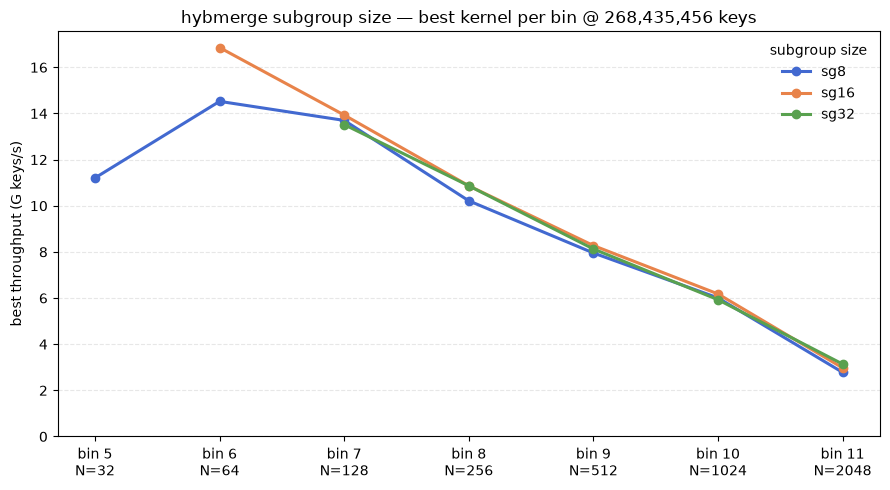

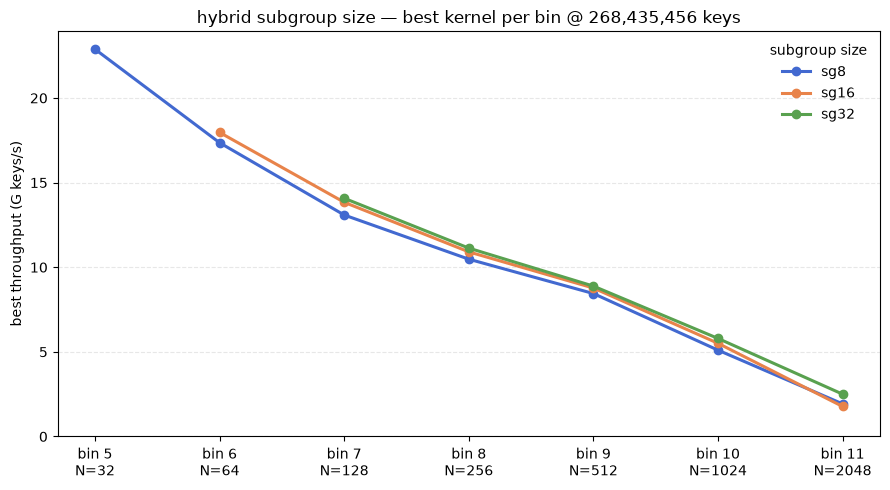

In [8]:
def plot_subgroup_study(agg, family):
    ref_nk = max(key_counts)
    sub = agg[(agg["family"] == family) & (agg["n_keys"] == ref_nk)]
    if sub.empty:
        return None
    best = (sub.groupby(["bin", "subgroups"])["gkeys_s"].max()
               .unstack("subgroups").sort_index())

    idx = list(best.index)
    x = np.arange(len(idx))
    labels = [f"bin {b}\nN={seg[b]}" for b in idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    for sg in sorted(best.columns):
        ax.plot(x, best[sg], marker="o", markersize=6, linewidth=2.2,
                color=SG_COLORS.get(sg, "#888"), label=f"sg{sg}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("best throughput (G keys/s)")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{family} subgroup size — best kernel per bin @ {ref_nk:,} keys")
    ax.legend(frameon=False, title="subgroup size", loc="upper right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return best


plot_subgroup_study(agg, "hybmerge")
plot_subgroup_study(agg, "hybrid")

## Best kernel per bin, by memory strategy

Grouped bars: one group per bin, one bar per memory strategy, each the best
throughput that strategy achieved in that bin at the largest key count.

memory,reg,smem,hybrid,hybmerge
bin,,,,
1,21.113402,19.883495,NaN,NaN
2,25.680503,25.600000,NaN,NaN
3,27.675676,27.675676,NaN,NaN
4,29.049645,26.256410,NaN,NaN
5,25.761006,20.078431,22.882682,11.206587
6,19.140187,14.894545,17.964912,16.855967
7,11.838150,11.314917,14.075601,13.931973
8,7.937984,8.445361,11.130435,10.864721
9,5.483266,6.838063,8.885033,8.274747


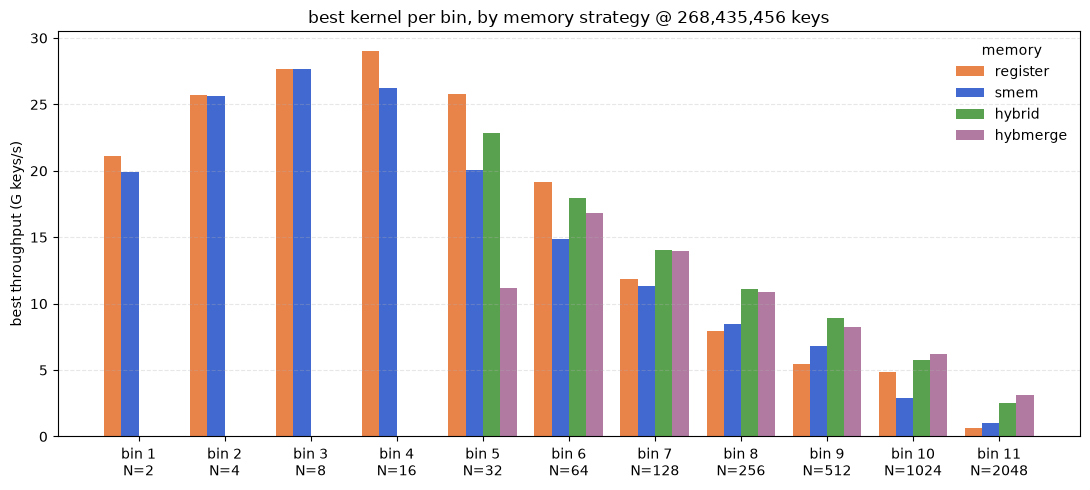

In [9]:
def plot_memory_by_bin(agg):
    ref_nk = max(key_counts)
    sub = agg[agg["n_keys"] == ref_nk]
    best = sub.groupby(["bin", "memory"])["gkeys_s"].max().unstack("memory").sort_index()
    order = [m for m in ["reg", "smem", "hybrid", "hybmerge"] if m in best.columns]
    best = best[order]

    idx = list(best.index)
    x = np.arange(len(idx))
    width = 0.8 / len(order)

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, mem in enumerate(order):
        ax.bar(x + (i - (len(order) - 1) / 2) * width, best[mem], width,
               color=FAMILY_COLORS.get(mem, "#888"), label=FAMILY_LABEL.get(mem, mem))
    ax.set_xticks(x)
    ax.set_xticklabels([f"bin {b}\nN={seg[b]}" for b in idx])
    ax.set_ylabel("best throughput (G keys/s)")
    ax.set_title(f"best kernel per bin, by memory strategy @ {ref_nk:,} keys")
    ax.legend(frameon=False, title="memory", loc="upper right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return best


plot_memory_by_bin(agg)

## Speedup heatmaps vs smem

One panel per **memory × store**. Color = log2 speedup of that combination's
best kernel over the best **smem** kernel *of the same store*, over segment
size (x) and key count (y). **blue = faster than smem, red = slower.**

,memory,store,bin,n_keys,gkeys_s,base,speedup
0,hybmerge,block,5,12400000,7.277269,21.023220,0.346154
1,hybmerge,block,5,102400000,11.081560,17.170330,0.645390
2,hybmerge,block,5,268435456,11.130435,20.078431,0.554348
3,hybmerge,block,6,12400000,15.767415,17.200817,0.916667
4,hybmerge,block,6,102400000,16.276042,12.913223,1.260417
5,hybmerge,block,6,268435456,16.855967,14.894545,1.131687
6,hybmerge,block,7,12400000,10.511610,9.958368,1.055556
7,hybmerge,block,7,102400000,13.354701,9.704969,1.376068
8,hybmerge,block,7,268435456,13.884746,11.314917,1.227119
9,hybmerge,block,8,12400000,7.568281,5.649230,1.339701


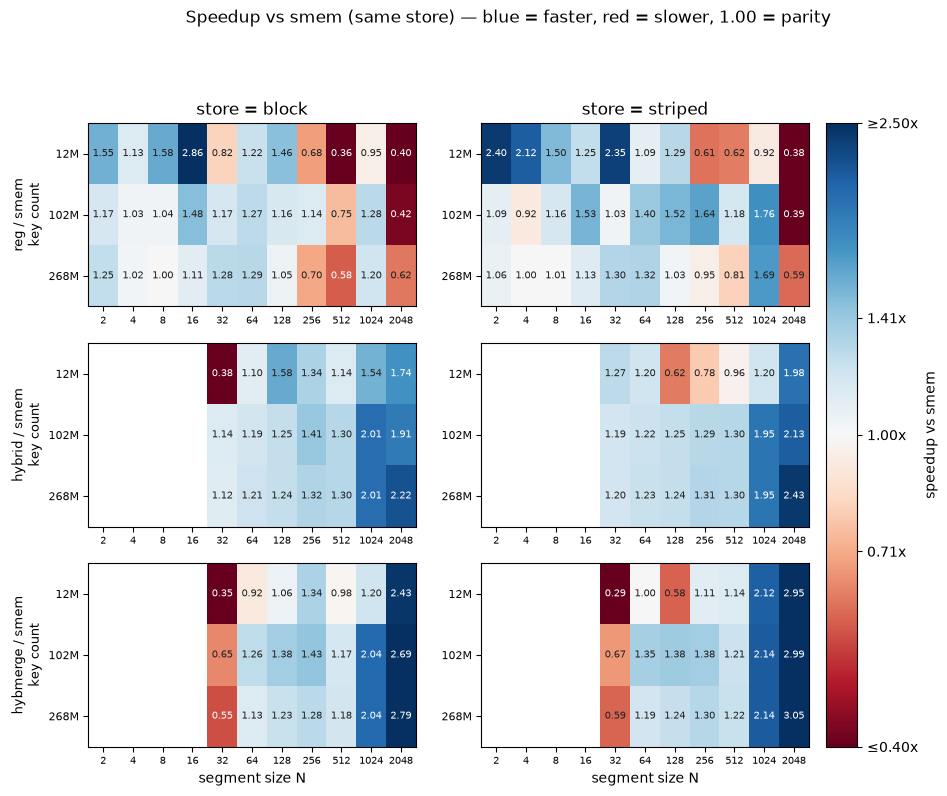

In [10]:
def speedup_heatmaps(agg, baseline="smem", saturate=2.5):
    best = agg.groupby(["memory", "store", "bin", "n_keys"])["gkeys_s"].max().reset_index()
    base = (best[best["memory"] == baseline]
            .rename(columns={"gkeys_s": "base"}).drop(columns="memory"))
    m = best[best["memory"] != baseline].merge(base, on=["store", "bin", "n_keys"])
    m["speedup"] = m["gkeys_s"] / m["base"]

    memories = [x for x in ["reg", "hybrid", "hybmerge"] if x in m["memory"].values]
    stores = [x for x in ["block", "striped"] if x in m["store"].values]
    lim = float(np.log2(saturate))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    nrows, ncols = len(memories), len(stores)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 2.7 * nrows), squeeze=False)
    im = None
    for r, mem in enumerate(memories):
        for c, st in enumerate(stores):
            ax = axes[r][c]
            s = m[(m["memory"] == mem) & (m["store"] == st)]
            Z = s.pivot(index="n_keys", columns="bin", values="speedup").reindex(
                index=key_counts, columns=bins)
            logZ = np.log2(Z.values)
            im = ax.imshow(logZ, cmap="RdBu", norm=norm, aspect="auto")
            for i in range(Z.shape[0]):
                for j in range(Z.shape[1]):
                    v = Z.values[i, j]
                    if np.isnan(v):
                        continue
                    ink = "white" if abs(logZ[i, j]) > 0.6 * lim else "#222"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color=ink)
            ax.set_xticks(range(len(bins)))
            ax.set_xticklabels([seg[b] for b in bins], fontsize=7)
            ax.set_yticks(range(len(key_counts)))
            ax.set_yticklabels([f"{k // 10**6}M" for k in key_counts], fontsize=8)
            if r == 0:
                ax.set_title(f"store = {st}")
            if c == 0:
                ax.set_ylabel(f"{mem} / smem\nkey count", fontsize=9)
            if r == nrows - 1:
                ax.set_xlabel("segment size N")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.02)
    cbar.set_ticks(np.log2([1 / saturate, 0.71, 1.0, 1.41, saturate]))
    cbar.ax.set_yticklabels(["≤0.40x", "0.71x", "1.00x", "1.41x", "≥2.50x"])
    cbar.set_label(f"speedup vs {baseline}")
    fig.suptitle(f"Speedup vs {baseline} (same store) — blue = faster, "
                 f"red = slower, 1.00 = parity", y=1.02)
    return m


speedup_heatmaps(agg)

## Winner stability across key counts

- `winner_table` — winning kernel per (bin, key count); `stable` = never changes.
- `plot_winner_stability` — regret heatmap: committing to one kernel per bin,
  what % of each cell's achievable throughput you get (100% = optimal).

In [11]:
def winner_table(agg):
    tab = winners.pivot(index="bin", columns="n_keys", values="kernel")
    tab.columns = [f"{k // 10**6}M" for k in tab.columns]
    tab["stable"] = tab.nunique(axis=1) == 1
    return tab


def geomean_winners(agg):
    """Per bin, the kernel maximizing the geomean of its median throughput across
    key counts (only kernels present at every key count). Prebuilt as geo_win."""
    return geo_win


def plot_winner_stability(agg, commit_at="max"):
    if commit_at == "geomean":
        committed = geo_win["kernel"]
        commit_desc = "geomean-best"
    else:
        commit_nk = max(key_counts) if commit_at == "max" else min(key_counts)
        committed = winners[winners["n_keys"] == commit_nk].set_index("bin")["kernel"]
        commit_desc = f"{commit_nk // 10**6}M"
    win_by_cell = winners.set_index(["bin", "n_keys"])["kernel"]

    regret = pd.DataFrame(index=bins, columns=key_counts, dtype=float)
    label = pd.DataFrame(index=bins, columns=key_counts, dtype=object)
    for b in bins:
        k = committed.get(b)
        for nk in key_counts:
            got = agg[(agg["bin"] == b) & (agg["n_keys"] == nk)
                      & (agg["kernel"] == k)]["gkeys_s"]
            frac = (got.iloc[0] / cell_best[(b, nk)]) if len(got) else float("nan")
            regret.loc[b, nk] = 100 * frac
            label.loc[b, nk] = win_by_cell[(b, nk)].replace("segsort_", "")

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(bins) + 1))
    im = ax.imshow(regret.values.astype(float), cmap="RdYlGn", vmin=40, vmax=100, aspect="auto")
    for i, b in enumerate(bins):
        for j, nk in enumerate(key_counts):
            ax.text(j, i, f"{label.loc[b, nk]}\n{regret.loc[b, nk]:.0f}%",
                    ha="center", va="center", fontsize=6.5, color="#111")
    ax.set_xticks(range(len(key_counts)))
    ax.set_xticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_yticks(range(len(bins)))
    ax.set_yticklabels([f"bin {b} (N={seg[b]})" for b in bins])
    ax.set_xlabel("key count")
    ax.set_title(f"Winner per (bin, key count) + regret of committing to the "
                 f"{commit_desc} winner\n"
                 f"(green = still optimal, red = throughput left on the table)")
    fig.colorbar(im, ax=ax, pad=0.02).set_label("% of per-cell best throughput")
    fig.tight_layout()
    return regret


print(winner_table(agg).to_string())
print("\nRobust (geomean-across-key-counts) winner per bin:")
print(geo_win.round(2).to_string())
plot_winner_stability(agg, commit_at="geomean")

## Striped vs block store — reg kernels

Diverging heatmap of the best reg kernel's striped/block throughput over
segment size (x) and key count (y). **blue = striped faster, red = block.**

,bin,n_keys,block,striped,ratio
0,1,12400000,9.460449,18.920898,2.000000
1,1,102400000,20.032051,21.114865,1.054054
2,1,268435456,21.113402,21.113402,1.000000
3,2,12400000,12.613932,23.651123,1.875000
4,2,102400000,26.041667,23.497569,0.902307
5,2,268435456,25.680503,25.600000,0.996865
6,3,12400000,19.972059,18.920898,0.947368
7,3,102400000,28.409091,28.409091,1.000000
8,3,268435456,27.675676,27.675676,1.000000
9,4,12400000,27.029855,11.825562,0.437500


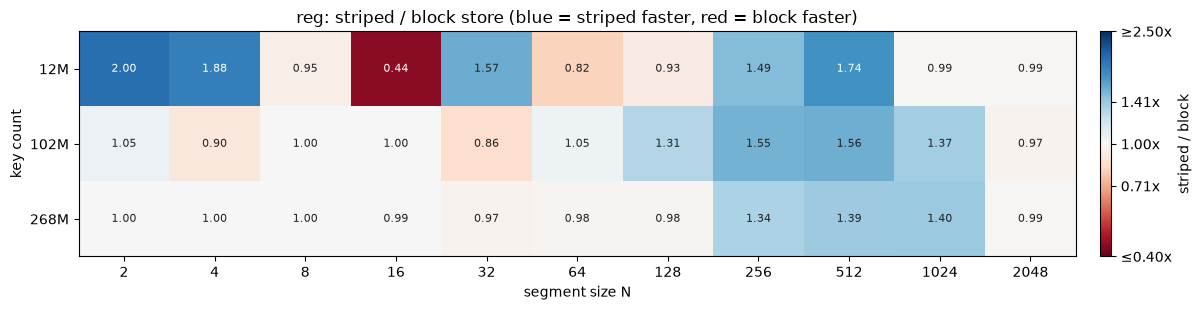

In [12]:
def plot_store_heatmap(agg, memory="reg", saturate=2.5):
    sub = agg[agg["memory"] == memory]
    best = sub.groupby(["store", "bin", "n_keys"])["gkeys_s"].max().reset_index()
    blk = best[best["store"] == "block"].rename(columns={"gkeys_s": "block"}).drop(columns="store")
    strp = best[best["store"] == "striped"].rename(columns={"gkeys_s": "striped"}).drop(columns="store")
    m = blk.merge(strp, on=["bin", "n_keys"])
    m["ratio"] = m["striped"] / m["block"]

    b_idx = sorted(m["bin"].unique())
    Z = m.pivot(index="n_keys", columns="bin", values="ratio").reindex(
        index=key_counts, columns=b_idx)
    logZ = np.log2(Z.values)
    lim = float(np.log2(saturate))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, ax = plt.subplots(figsize=(1.0 * len(b_idx) + 2, 3.2))
    im = ax.imshow(logZ, cmap="RdBu", norm=norm, aspect="auto")
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z.values[i, j]
            if np.isnan(v):
                continue
            ink = "white" if abs(logZ[i, j]) > 0.6 * lim else "#222"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=ink)
    ax.set_xticks(range(len(b_idx)))
    ax.set_xticklabels([seg[b] for b in b_idx])
    ax.set_yticks(range(len(key_counts)))
    ax.set_yticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_xlabel("segment size N")
    ax.set_ylabel("key count")
    ax.set_title(f"{memory}: striped / block store (blue = striped faster, red = block faster)")
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_ticks(np.log2([1 / saturate, 0.71, 1.0, 1.41, saturate]))
    cbar.ax.set_yticklabels(["≤0.40x", "0.71x", "1.00x", "1.41x", "≥2.50x"])
    cbar.set_label("striped / block")
    fig.tight_layout()
    return m


plot_store_heatmap(agg, memory="reg")

## Achievable-throughput envelope + roofline

Best throughput across all families/stores per bin, markers colored by winning
family, with the ceiling. Thin gray lines = envelope at the smaller key counts.

                                                  12M                                              102M                                              268M  stable
bin                                                                                                                                                              
1                           segsort_reg_n2_m2_striped                         segsort_reg_n2_m2_striped                           segsort_reg_n2_m2_block   False
2                           segsort_reg_n4_m4_striped                           segsort_reg_n4_m4_block                           segsort_reg_n4_m4_block   False
3                             segsort_reg_n8_m8_block                           segsort_reg_n8_m8_block                           segsort_reg_n8_m8_block    True
4                           segsort_reg_n16_m16_block                         segsort_reg_n16_m16_block                          segsort_reg_n16_m8_block   False
5                         se

,12400000,102400000,268435456
1,100.0,100.000000,100.000000
2,100.0,90.230665,99.686520
3,100.0,100.000000,100.000000
4,100.0,100.000000,98.601399
5,100.0,85.724638,93.529412
6,100.0,95.260250,100.000000
7,100.0,82.556320,100.000000
8,100.0,84.076433,97.612732
9,100.0,94.907407,95.051546
10,100.0,100.000000,100.000000


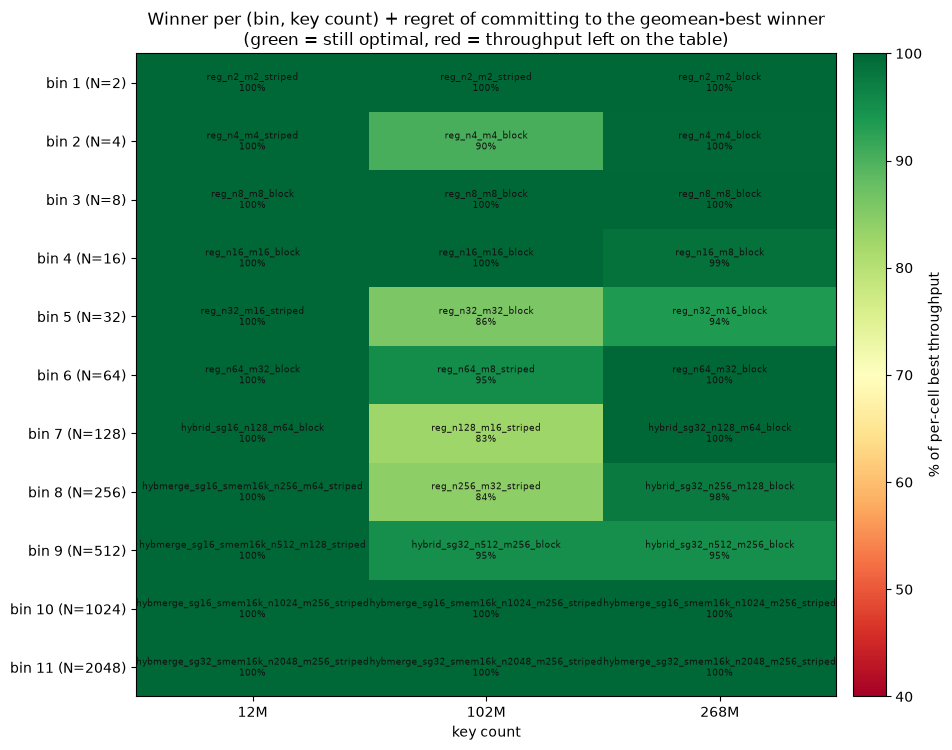

In [13]:
def plot_envelope(agg, ref_at="max"):
    ref_nk = max(key_counts) if ref_at == "max" else min(key_counts)
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for nk in key_counts:
        if nk == ref_nk:
            continue
        e = agg[agg["n_keys"] == nk]
        env = e.loc[e.groupby("N")["gkeys_s"].idxmax()].sort_values("N")
        ax.plot(env["N"], env["gkeys_s"], color="#bbb", linewidth=1.0, zorder=1,
                label=f"{nk // 10**6}M (envelope)")

    e = agg[agg["n_keys"] == ref_nk]
    env = e.loc[e.groupby("N")["gkeys_s"].idxmax()].sort_values("N")
    ax.plot(env["N"], env["gkeys_s"], color="#333", linewidth=1.6, zorder=2,
            label=f"{ref_nk // 10**6}M (best)")
    seen = set()
    for _, row in env.iterrows():
        fam = row["family"]
        ax.scatter(row["N"], row["gkeys_s"], s=70, zorder=3,
                   color=FAMILY_COLORS.get(fam, "#888"), edgecolor="white", linewidth=0.8,
                   label=FAMILY_LABEL.get(fam, fam) if fam not in seen else None)
        seen.add(fam)

    if CEIL_GKEYS <= ax.get_ylim()[1] * 1.2:
        ax.axhline(CEIL_GKEYS, color="#999", linestyle="--", linewidth=1.2)
        ax.text(env["N"].min(), CEIL_GKEYS, f" {CEIL_GKEYS:.1f} G keys/s ceiling",
                va="bottom", ha="left", fontsize=8, color="#777")

    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel("best throughput (G keys/s)")
    ax.set_title(f"Achievable throughput envelope @ {ref_nk // 10**6}M keys "
                 f"(marker color = winning family)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    fig.tight_layout()
    return env


plot_envelope(agg)

## Envelope: per-size winner vs robust (geomean) winner

Both lines are throughput at the given key count. Solid = per-size winner
(optimal by construction); dashed = geomean-robust winner's throughput here.
The gap is what the robust choice costs at that input size.

,bin,N,n_keys,family,kernel,gkeys_s
8,1,2,268435456,reg,segsort_reg_n2_m2_block,21.113402
24,2,4,268435456,reg,segsort_reg_n4_m4_block,25.680503
46,3,8,268435456,reg,segsort_reg_n8_m8_block,27.675676
84,4,16,268435456,reg,segsort_reg_n16_m8_block,29.049645
148,5,32,268435456,reg,segsort_reg_n32_m16_block,25.761006
246,6,64,268435456,reg,segsort_reg_n64_m32_block,19.140187
368,7,128,268435456,hybrid,segsort_hybrid_sg32_n128_m64_block,14.075601
536,8,256,268435456,hybrid,segsort_hybrid_sg32_n256_m128_block,11.130435
754,9,512,268435456,hybrid,segsort_hybrid_sg32_n512_m256_block,8.885033
939,10,1024,268435456,hybmerge,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,6.177979


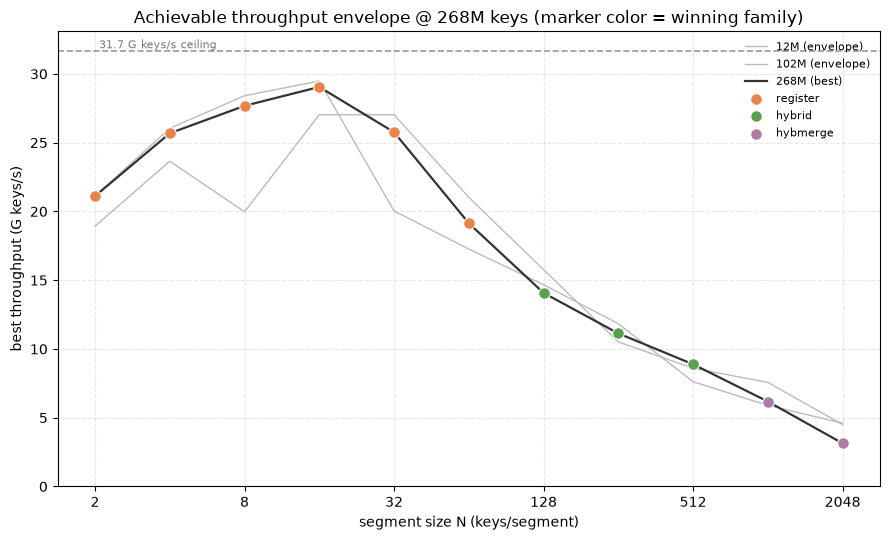

In [14]:
def plot_envelope_compare(agg, n_keys=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    sub = agg[agg["n_keys"] == nk]
    win = sub.loc[sub.groupby("N")["gkeys_s"].idxmax()].sort_values("N")

    gw = geo_win["kernel"]
    geo_rows = []
    for b, kern in gw.items():
        r = sub[(sub["bin"] == b) & (sub["kernel"] == kern)]
        if not r.empty:
            geo_rows.append(r.iloc[0])
    geo = pd.DataFrame(geo_rows).sort_values("N")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(win["N"], win["gkeys_s"], marker="o", color="#333", linewidth=2.0,
            zorder=3, label=f"per-size winner @ {nk // 10**6}M")
    ax.plot(geo["N"], geo["gkeys_s"], marker="s", color="#c44", linewidth=2.0,
            linestyle="--", zorder=3, label="geomean (robust) winner")
    seen = set()
    for _, row in win.iterrows():
        fam = row["family"]
        ax.scatter(row["N"], row["gkeys_s"], s=70, zorder=4,
                   color=FAMILY_COLORS.get(fam, "#888"), edgecolor="white", linewidth=0.8,
                   label=FAMILY_LABEL.get(fam, fam) if fam not in seen else None)
        seen.add(fam)

    if CEIL_GKEYS <= ax.get_ylim()[1] * 1.2:
        ax.axhline(CEIL_GKEYS, color="#999", linestyle=":", linewidth=1.0)
        ax.text(win["N"].min(), CEIL_GKEYS, f" {CEIL_GKEYS:.1f} ceiling",
                va="bottom", ha="left", fontsize=8, color="#777")

    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel(f"throughput @ {nk // 10**6}M (G keys/s)")
    ax.set_title(f"Achievable envelope: per-size winner vs robust geomean winner "
                 f"@ {nk // 10**6}M\n(winner markers colored by family)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()

    out = win[["N", "kernel", "gkeys_s"]].merge(
        geo[["N", "kernel", "gkeys_s"]], on="N", suffixes=("_winner", "_geomean"))
    out["geomean/winner"] = out["gkeys_s_geomean"] / out["gkeys_s_winner"]
    return out


plot_envelope_compare(agg, n_keys=max(key_counts))
plot_envelope_compare(agg, n_keys=key_counts[0])
plot_envelope_compare(agg, n_keys=key_counts[1])

## M / WPT tuning: throughput over (N x M) per family

Median throughput over (N, M) per family at the largest key count (median of
the kernel medians sharing that N×M). `*` marks the best M for each N.

,N,kernel_winner,gkeys_s_winner,kernel_geomean,gkeys_s_geomean,geomean/winner
0,2,segsort_reg_n2_m2_block,21.113402,segsort_reg_n2_m2_striped,21.113402,1.000000
1,4,segsort_reg_n4_m4_block,25.680503,segsort_reg_n4_m4_striped,25.600000,0.996865
2,8,segsort_reg_n8_m8_block,27.675676,segsort_reg_n8_m8_block,27.675676,1.000000
3,16,segsort_reg_n16_m8_block,29.049645,segsort_reg_n16_m16_block,28.643357,0.986014
4,32,segsort_reg_n32_m16_block,25.761006,segsort_reg_n32_m16_striped,24.094118,0.935294
5,64,segsort_reg_n64_m32_block,19.140187,segsort_reg_n64_m32_block,19.140187,1.000000
6,128,segsort_hybrid_sg32_n128_m64_block,14.075601,segsort_hybrid_sg32_n128_m64_block,14.075601,1.000000
7,256,segsort_hybrid_sg32_n256_m128_block,11.130435,segsort_hybmerge_sg16_smem16k_n256_m64_striped,10.864721,0.976127
8,512,segsort_hybrid_sg32_n512_m256_block,8.885033,segsort_hybrid_sg8_n512_m256_block,8.445361,0.950515
9,1024,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,6.177979,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,6.177979,1.000000


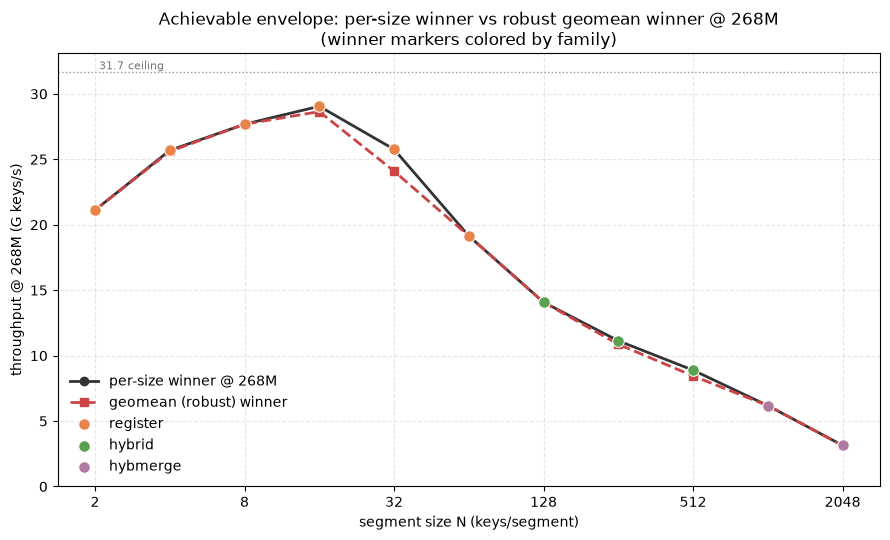

In [15]:
def plot_mn_tuning(agg, memory, n_keys=None, ax=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    sub = agg[(agg["memory"] == memory) & (agg["n_keys"] == nk)]
    if sub.empty:
        return None
    cell = sub.groupby(["N", "M"])["gkeys_s"].median().reset_index()
    Ns = sorted(cell["N"].unique())
    Ms = sorted(cell["M"].unique())
    Z = cell.pivot(index="M", columns="N", values="gkeys_s").reindex(index=Ms, columns=Ns)

    if ax is None:
        _, ax = plt.subplots(figsize=(1.0 * len(Ns) + 2, 0.5 * len(Ms) + 2))
    im = ax.imshow(Z.values.astype(float), cmap="viridis", aspect="auto", origin="lower")
    for j, N in enumerate(Ns):
        col = Z[N]
        best_m = col.idxmax() if col.notna().any() else None
        for i, M in enumerate(Ms):
            v = Z.loc[M, N]
            if np.isnan(v):
                continue
            star = "*" if M == best_m else ""
            ax.text(j, i, f"{v:.1f}{star}", ha="center", va="center", fontsize=7,
                    color="white" if v < np.nanmax(Z.values) * 0.6 else "#111")
    ax.set_xticks(range(len(Ns)))
    ax.set_xticklabels(Ns)
    ax.set_yticks(range(len(Ms)))
    ax.set_yticklabels(Ms)
    ax.set_xlabel("segment size N")
    ax.set_ylabel("lanes M")
    ax.set_title(f"{memory}: throughput (G keys/s) over N x M @ {nk // 10**6}M (* = best M per N)")
    plt.colorbar(im, ax=ax, pad=0.02, label="G keys/s")
    plt.tight_layout()
    return Z


for _mem in ["reg", "smem", "hybrid", "hybmerge"]:
    plot_mn_tuning(agg, _mem)
    plt.show()

## Register vs shared memory (Hou et al Fig 9 analog)

Typical throughput vs segment size at the largest key count for **register**,
**smem**, and **hybmerge** (merge-path, ~Hou et al's shared-memory kernel).

,N,kernel_winner,gkeys_s_winner,kernel_geomean,gkeys_s_geomean,geomean/winner
0,2,segsort_reg_n2_m2_striped,21.114865,segsort_reg_n2_m2_striped,21.114865,1.000000
1,4,segsort_reg_n4_m4_block,26.041667,segsort_reg_n4_m4_striped,23.497569,0.902307
2,8,segsort_reg_n8_m8_block,28.409091,segsort_reg_n8_m8_block,28.409091,1.000000
3,16,segsort_reg_n16_m16_block,29.481132,segsort_reg_n16_m16_block,29.481132,1.000000
4,32,segsort_reg_n32_m32_block,20.032051,segsort_reg_n32_m16_striped,17.172403,0.857246
5,64,segsort_reg_n64_m8_striped,17.265720,segsort_reg_n64_m32_block,16.447368,0.952603
6,128,segsort_reg_n128_m16_striped,14.671685,segsort_hybrid_sg32_n128_m64_block,12.112403,0.825563
7,256,segsort_reg_n256_m32_striped,11.837121,segsort_hybmerge_sg16_smem16k_n256_m64_striped,9.952229,0.840764
8,512,segsort_hybrid_sg32_n512_m256_block,7.621951,segsort_hybrid_sg8_n512_m256_block,7.233796,0.949074
9,1024,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,5.896226,segsort_hybmerge_sg16_smem16k_n1024_m256_striped,5.896226,1.000000


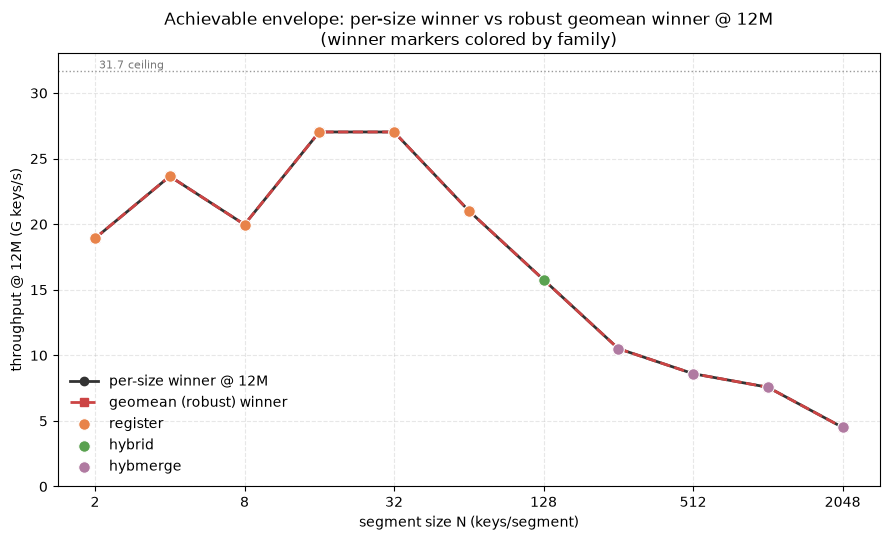

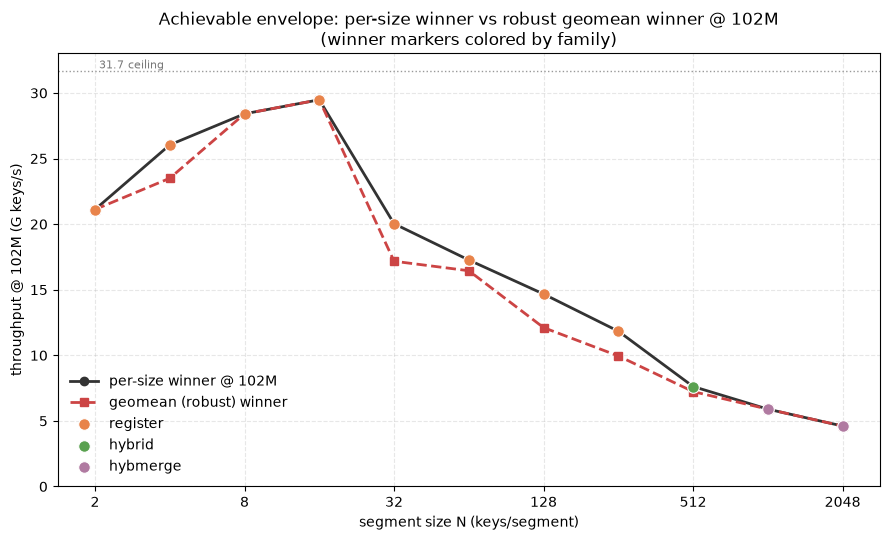

In [16]:
def plot_reg_vs_smem(agg, n_keys=None):
    nk = n_keys if n_keys is not None else max(key_counts)
    mems = ["reg", "smem", "hybmerge"]
    sub = agg[(agg["memory"].isin(mems)) & (agg["n_keys"] == nk)]
    best = sub.groupby(["memory", "N"])["gkeys_s"].median().reset_index()
    piv = best.pivot(index="N", columns="memory", values="gkeys_s").sort_index()

    labels = {"reg": "register", "smem": "smem",
              "hybmerge": "hybmerge (merge-path, ~Hou et al)"}
    fig, ax = plt.subplots(figsize=(8, 5))
    for m in mems:
        if m not in piv:
            continue
        s = piv[m].dropna()
        ax.plot(s.index, s.values, marker="o", color=FAMILY_COLORS[m],
                linewidth=2.2, label=labels[m])
    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel("throughput (G keys/s)")
    ax.set_title(f"Register vs shared memory @ {nk // 10**6}M keys")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)
    fig.tight_layout()
    if "smem" in piv:
        piv["reg/smem"] = piv["reg"] / piv["smem"]
    if "hybmerge" in piv:
        piv["reg/hybmerge"] = piv["reg"] / piv["hybmerge"]
    return piv


plot_reg_vs_smem(agg)

## Family decision map — who wins over (N x key count)

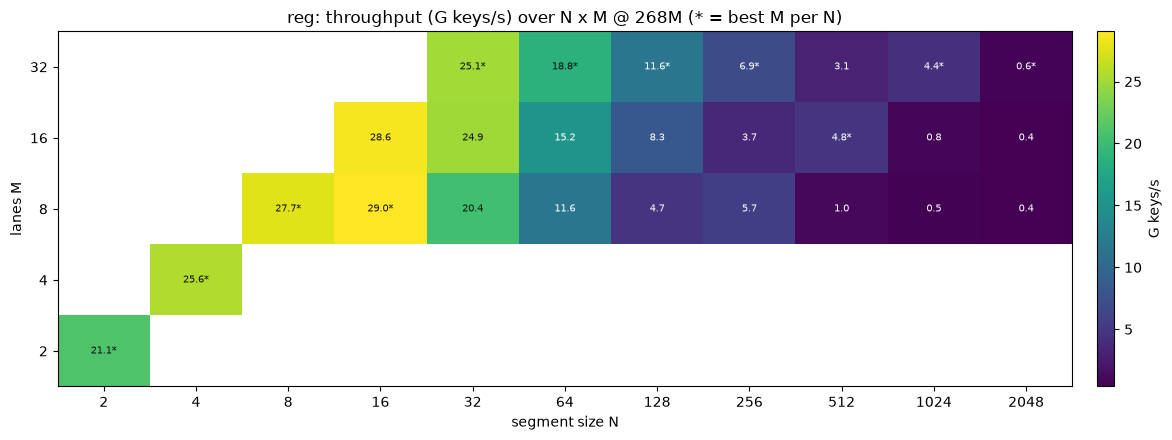

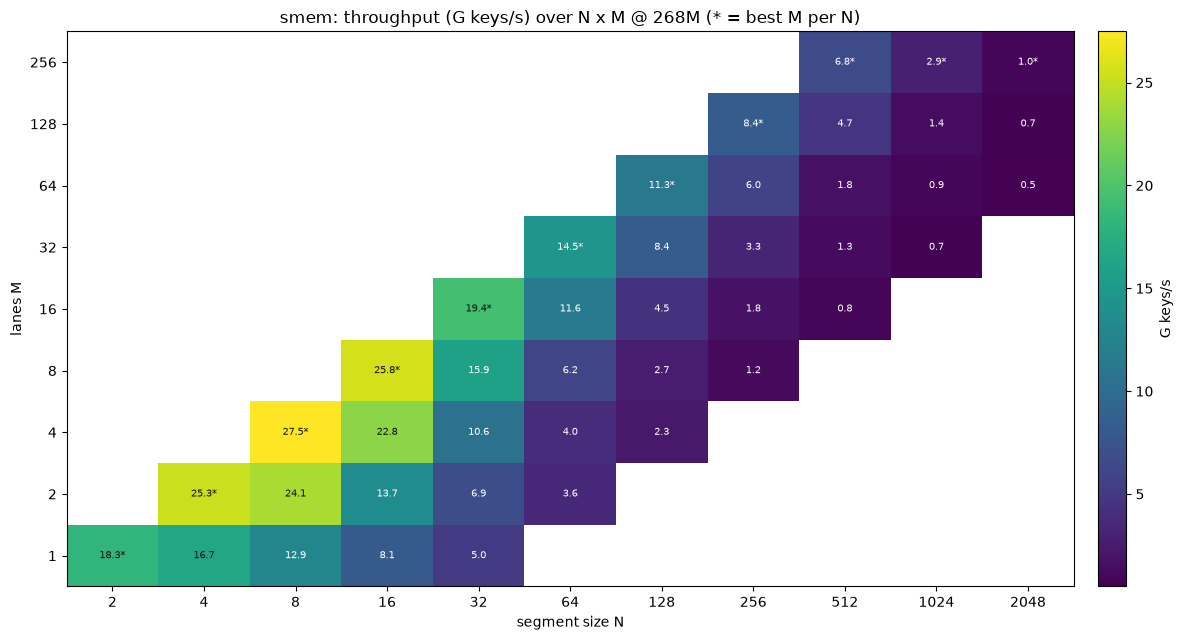

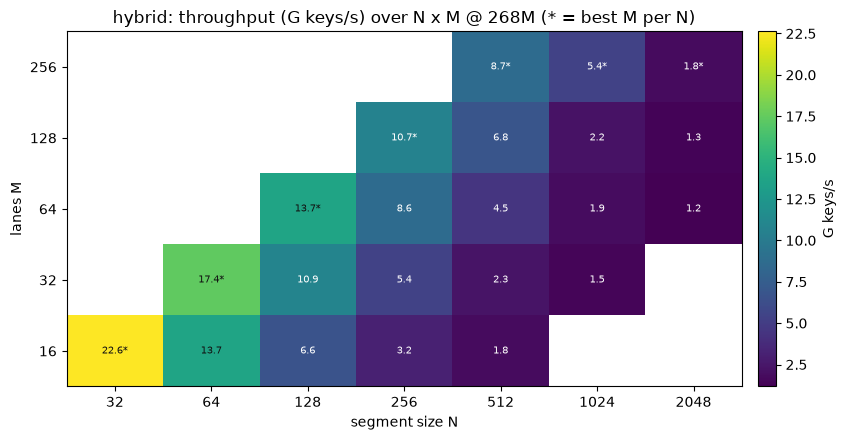

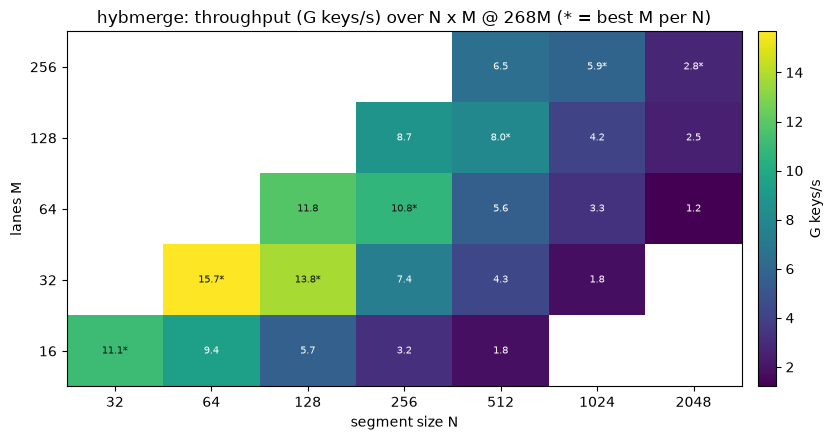

In [17]:
def plot_decision_map(agg):
    fam_order = ["reg", "smem", "hybrid", "hybmerge"]
    cmap = ListedColormap([FAMILY_COLORS[f] for f in fam_order])
    norm = BoundaryNorm(range(len(fam_order) + 1), cmap.N)

    fam_best = agg.groupby(["bin", "n_keys", "family"])["gkeys_s"].max().reset_index()
    win = fam_best.loc[fam_best.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()]
    b_idx = sorted(win["bin"].unique())
    fam_idx = {f: i for i, f in enumerate(fam_order)}

    Z = np.full((len(key_counts), len(b_idx)), np.nan)
    lbl = {}
    for _, row in win.iterrows():
        i = key_counts.index(row["n_keys"])
        j = b_idx.index(row["bin"])
        Z[i, j] = fam_idx[row["family"]]
        lbl[(i, j)] = row["family"][0].upper()

    fig, ax = plt.subplots(figsize=(1.0 * len(b_idx) + 2, 3))
    ax.imshow(Z, cmap=cmap, norm=norm, aspect="auto")
    for (i, j), t in lbl.items():
        ax.text(j, i, t, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.set_xticks(range(len(b_idx)))
    ax.set_xticklabels([seg[b] for b in b_idx])
    ax.set_yticks(range(len(key_counts)))
    ax.set_yticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_xlabel("segment size N")
    ax.set_ylabel("key count")
    ax.set_title("Winning family per (N, key count)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=FAMILY_COLORS[f]) for f in fam_order]
    ax.legend(handles, fam_order, frameon=False, fontsize=8,
              loc="center left", bbox_to_anchor=(1.01, 0.5))
    fig.tight_layout()
    return win


plot_decision_map(agg)

## smem budget: 32k vs 16k (same kernel, larger workgroup)

The 32k rows run the same wg/hybrid kernels as their 16k twins with a bigger
workgroup. Each point = one config's 32k/16k throughput ratio; below 1.0 = the
bigger workgroup hurt (lower occupancy). The penalty deepens with key count.

memory,hybmerge,reg,smem,reg/smem,reg/hybmerge
N,,,,,
2,NaN,21.113402,18.274137,1.155371,NaN
4,NaN,25.600000,21.470261,1.192347,NaN
8,NaN,27.675676,24.094118,1.148649,NaN
16,NaN,28.845070,13.676470,2.109102,NaN
32,11.130435,24.530464,7.961824,3.081011,2.203909
64,14.473679,15.226766,5.251659,2.899420,1.052031
128,12.646299,7.348010,3.578727,2.053247,0.581040
256,8.687257,5.458339,2.366836,2.306175,0.628316
512,5.970845,3.077820,1.682761,1.829030,0.515475


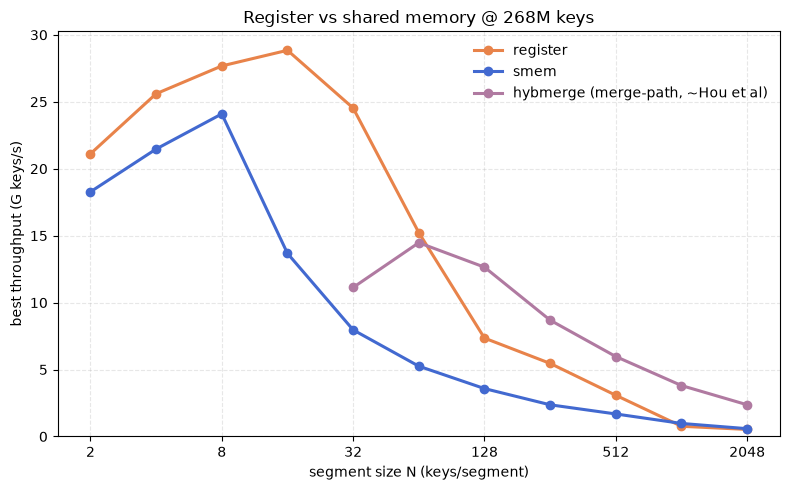

In [18]:
def plot_smem_budget_compare(agg):
    d = agg.copy()
    d["base"] = d["kernel"].str.replace("_smem32k", "", regex=False)
    d["budget"] = np.where(d["kernel"].str.endswith("_smem32k"), "32k", "16k")
    has32 = set(d.loc[d["budget"] == "32k", "base"])
    d = d[d["base"].isin(has32)]

    piv = d.pivot_table(index=["base", "memory", "n_keys"], columns="budget",
                        values="gkeys_s").reset_index()
    piv["ratio"] = piv["32k"] / piv["16k"]

    kcs = sorted(piv["n_keys"].unique())
    xpos = {nk: i for i, nk in enumerate(kcs)}
    rng = np.random.default_rng(0)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    for mem in ("smem", "hybrid"):
        s = piv[piv["memory"] == mem]
        x = [xpos[nk] + rng.uniform(-0.18, 0.18) for nk in s["n_keys"]]
        ax.scatter(x, s["ratio"], s=32, alpha=0.7, color=FAMILY_COLORS[mem],
                   label=FAMILY_LABEL[mem], edgecolor="white", linewidth=0.4)
    for nk in kcs:
        mval = piv.loc[piv["n_keys"] == nk, "ratio"].median()
        ax.plot([xpos[nk] - 0.3, xpos[nk] + 0.3], [mval, mval], color="#111", linewidth=2, zorder=5)
        ax.annotate(f"median {mval:.2f}", (xpos[nk], mval), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, fontweight="bold")

    ax.axhline(1.0, color="#999", linestyle="--", linewidth=1.2)
    ax.set_xticks(range(len(kcs)))
    ax.set_xticklabels([f"{nk // 10**6}M" for nk in kcs])
    ax.set_xlabel("key count")
    ax.set_ylabel("throughput ratio  32k / 16k")
    ax.set_title("Larger smem budget (bigger workgroup) vs 16k baseline\n"
                 "below 1.0 = 32k slower; each point = one wg/hybrid config")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, title="family")
    fig.tight_layout()
    return piv.sort_values(["memory", "n_keys", "ratio"])


smem_budget_ratios = plot_smem_budget_compare(agg)

### Conclusion: a larger shared-memory budget hurts throughput here

The 32k budget doesn't change the algorithm — it only lets `bench_wg` grow the
workgroup (WG 128→256, 64→128). Bigger workgroups mean **lower occupancy →
less latency hiding**, so throughput *drops*, worsening with input size (median
32k/16k ≈ 0.92 → 0.87 → **0.66** at 12.4M → 102M → 268M).

**Takeaway:** more shared memory is not helpful here — the grow-WG-to-fill-the-
budget policy in `bench_wg` is the wrong default for throughput; capping WG
lower would likely do better. A WG-size sweep at fixed budget is the follow-up.

## Run stability: coefficient of variation (CV) heatmaps

CV = 100 · std/mean of each experiment's ~50 runs (low = tight). Views: CV of
the best kernel per (bin, key count), and per family.

,bin,N,n_keys,family,gkeys_s
0,1,2,12400000,reg,12.007493
2,1,2,102400000,reg,20.833333
4,1,2,268435456,reg,21.113402
6,2,4,12400000,reg,13.514927
8,2,4,102400000,reg,25.614754
10,2,4,268435456,reg,25.600000
12,3,8,12400000,reg,18.920898
14,3,8,102400000,reg,28.409091
16,3,8,268435456,reg,27.675676
18,4,16,12400000,reg,17.200817


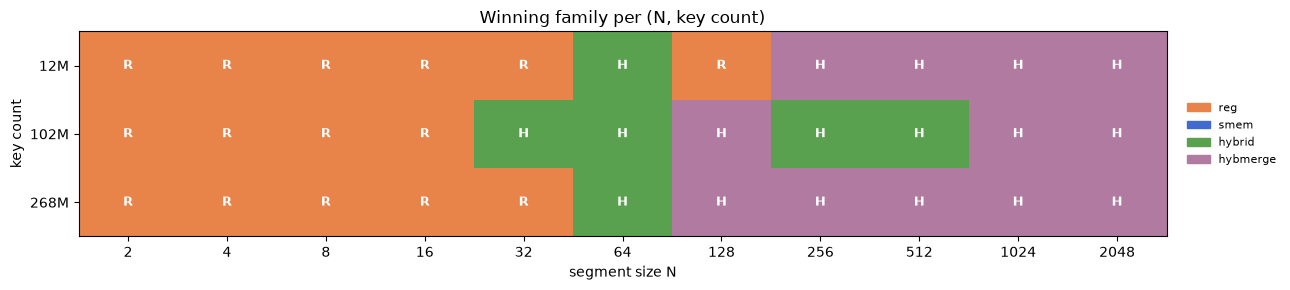

In [19]:
def _draw_cv(ax, Z, b_idx, key_counts, title, vmax):
    im = ax.imshow(Z, cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
                    color="#111" if v < 0.6 * vmax else "white")
    ax.set_xticks(range(len(key_counts)))
    ax.set_xticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_yticks(range(len(b_idx)))
    ax.set_yticklabels([f"bin {b} (N={seg[b]})" for b in b_idx])
    ax.set_title(title)
    return im


def plot_cv_heatmap_best(agg, vmax=None):
    win = agg.loc[agg.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()]
    Z = win.pivot(index="bin", columns="n_keys", values="cv").reindex(
        index=bins, columns=key_counts).values
    vmax = vmax or float(np.nanmax(Z))
    fig, ax = plt.subplots(figsize=(5, 0.5 * len(bins) + 1))
    im = _draw_cv(ax, Z, bins, key_counts, "CV % of the best kernel per (bin, key count)", vmax)
    ax.set_xlabel("key count")
    fig.colorbar(im, ax=ax, pad=0.02, label="CV %")
    fig.tight_layout()
    return Z


def plot_cv_heatmap_by_family(agg, vmax=None):
    fams = [f for f in ["reg", "smem", "hybrid", "hybmerge"] if f in agg["family"].unique()]
    zs = {}
    for fam in fams:
        sf = agg[agg["family"] == fam]
        w = sf.loc[sf.groupby(["bin", "n_keys"])["gkeys_s"].idxmax()]
        zs[fam] = w.pivot(index="bin", columns="n_keys", values="cv").reindex(
            index=bins, columns=key_counts).values
    vmax = vmax or float(np.nanmax([np.nanmax(z) for z in zs.values()]))

    fig, axes = plt.subplots(1, len(fams), figsize=(3.2 * len(fams), 0.5 * len(bins) + 1), sharey=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, fam in zip(axes, fams):
        im = _draw_cv(ax, zs[fam], bins, key_counts, FAMILY_LABEL.get(fam, fam), vmax)
        ax.set_xlabel("key count")
    for ax in axes[1:]:
        ax.set_ylabel("")
    fig.colorbar(im, ax=axes.tolist(), pad=0.02, label="CV %")
    fig.suptitle("CV % of the best kernel per family (blank = family absent in bin)", y=1.02)
    return zs


plot_cv_heatmap_best(agg)
plot_cv_heatmap_by_family(agg)

### CV of the geomean (robust) winner, and vs the per-size winner

**red = the robust choice is noisier, blue = tighter, 0 = same kernel.**

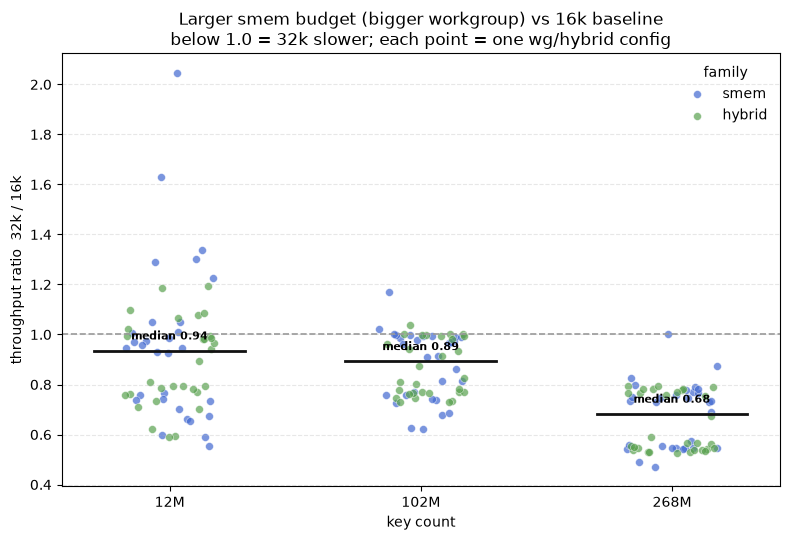

In [20]:
def _cv_pivot_for_kernels(agg, kernel_of):
    lut = agg.set_index(["bin", "n_keys", "kernel"])["cv"].to_dict()
    Z = np.full((len(bins), len(key_counts)), np.nan)
    for i, b in enumerate(bins):
        for j, nk in enumerate(key_counts):
            k = kernel_of(b, nk)
            if k is not None:
                Z[i, j] = lut.get((b, nk, k), np.nan)
    return Z


def plot_cv_heatmap_geomean(agg, vmax=None):
    gw = geo_win["kernel"]
    Z = _cv_pivot_for_kernels(agg, lambda b, nk: gw.get(b))
    vmax = vmax or float(np.nanmax(Z))
    fig, ax = plt.subplots(figsize=(5, 0.5 * len(bins) + 1))
    im = _draw_cv(ax, Z, bins, key_counts, "CV % of the geomean (robust) winner per bin", vmax)
    ax.set_xlabel("key count")
    fig.colorbar(im, ax=ax, pad=0.02, label="CV %")
    fig.tight_layout()
    return Z


def plot_cv_compare(agg):
    win_k = winners.set_index(["bin", "n_keys"])["kernel"].to_dict()
    gw = geo_win["kernel"]
    Zw = _cv_pivot_for_kernels(agg, lambda b, nk: win_k.get((b, nk)))
    Zg = _cv_pivot_for_kernels(agg, lambda b, nk: gw.get(b))
    D = Zg - Zw

    lim = float(np.nanmax(np.abs(D)))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    fig, ax = plt.subplots(figsize=(5.5, 0.5 * len(bins) + 1))
    im = ax.imshow(D, cmap="RdBu_r", norm=norm, aspect="auto")
    for i in range(D.shape[0]):
        for j in range(D.shape[1]):
            v = D[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=7,
                    color="#111" if abs(v) < 0.6 * lim else "white")
    ax.set_xticks(range(len(key_counts)))
    ax.set_xticklabels([f"{k // 10**6}M" for k in key_counts])
    ax.set_yticks(range(len(bins)))
    ax.set_yticklabels([f"bin {b} (N={seg[b]})" for b in bins])
    ax.set_xlabel("key count")
    ax.set_title("CV difference: geomean winner − per-size winner\n"
                 "(red = robust choice noisier, blue = tighter, 0 = same kernel)")
    fig.colorbar(im, ax=ax, pad=0.02).set_label("Δ CV % (geomean − winner)")
    fig.tight_layout()
    return D


plot_cv_heatmap_geomean(agg)
plot_cv_compare(agg)

## Roofline efficiency: % of the memory-bandwidth ceiling

Best throughput per bin as a fraction of the 31.7 G keys/s ceiling. High % =
memory-bandwidth bound; low % = compute/latency bound (headroom remains).

In [ ]:
def plot_roofline_efficiency(agg):
    fig, ax = plt.subplots(figsize=(9, 5))
    env = None
    for nk in key_counts:
        e = agg[agg["n_keys"] == nk]
        env = e.loc[e.groupby("N")["gkeys_s"].idxmax()].sort_values("N")
        ax.plot(env["N"], 100 * env["gkeys_s"] / CEIL_GKEYS, marker="o",
                linewidth=2.0, label=f"{nk // 10**6}M")
    ax.axhline(100, color="#999", linestyle="--", linewidth=1.2)
    ax.text(agg["N"].min(), 100, " roofline (100%)", va="bottom", ha="left", fontsize=8, color="#777")
    ax.set_xscale("log", base=2)
    ax.set_ylim(0, 110)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlabel("segment size N (keys/segment)")
    ax.set_ylabel("% of 31.7 G keys/s ceiling")
    ax.set_title("Roofline efficiency: best throughput as % of the memory-bandwidth ceiling")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, title="key count")
    fig.tight_layout()
    return env


plot_roofline_efficiency(agg)

## Wall vs GPU time: dispatch overhead (methods)

Median GPU-timestamp time vs wall time per experiment (µs, log-log). Points
above y=x carry host submit/wait overhead; the gap dominates at small
workloads — why 12.4M is noisier and why throughput uses `gpu_ns`.

{'reg': array([[ 8.73384425,  1.24264352,  3.99551191],
        [24.05157193,  1.09544314,  0.44314089],
        [28.16494258,  1.19934278,  0.6655975 ],
        [13.41170395,  1.01185825,  0.45768228],
        [20.11139054,  7.25002117,  0.29971071],
        [ 4.04261974,  7.12318578,  0.49159987],
        [ 0.        , 19.95098222,  4.51590525],
        [15.90681191,  0.54729153,  0.09859502],
        [17.05821711,  0.3296806 ,  0.22345793],
        [ 2.97396471,  0.39915223,  0.22945027],
        [ 1.21733536,  2.12682123,  2.63001019]]),
 'smem': array([[ 4.05738587,  3.60126023,  0.35375921],
        [ 5.0955626 ,  1.17692219,  0.4041566 ],
        [ 3.23713322,  1.20724712,  0.45314386],
        [ 1.68029642,  5.64162547,  8.4425422 ],
        [14.8506515 ,  4.95929134,  0.42657704],
        [ 4.38083376,  0.57850159,  0.27907834],
        [ 2.74877392,  0.48277126,  0.21858797],
        [ 2.36570952,  0.26020619,  0.12956346],
        [ 2.02481394,  0.28443319,  0.19642717],
   

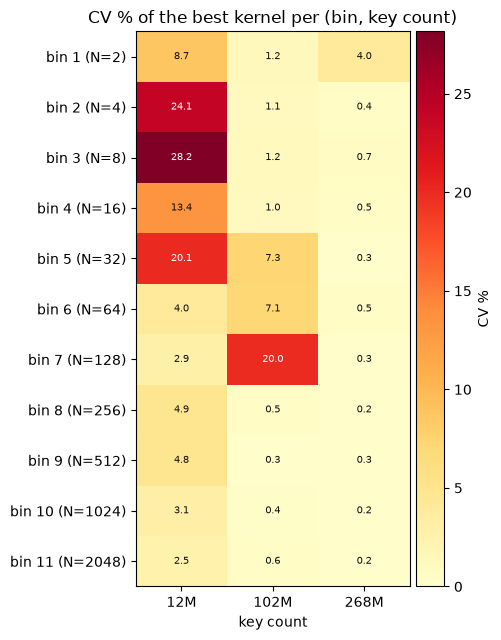

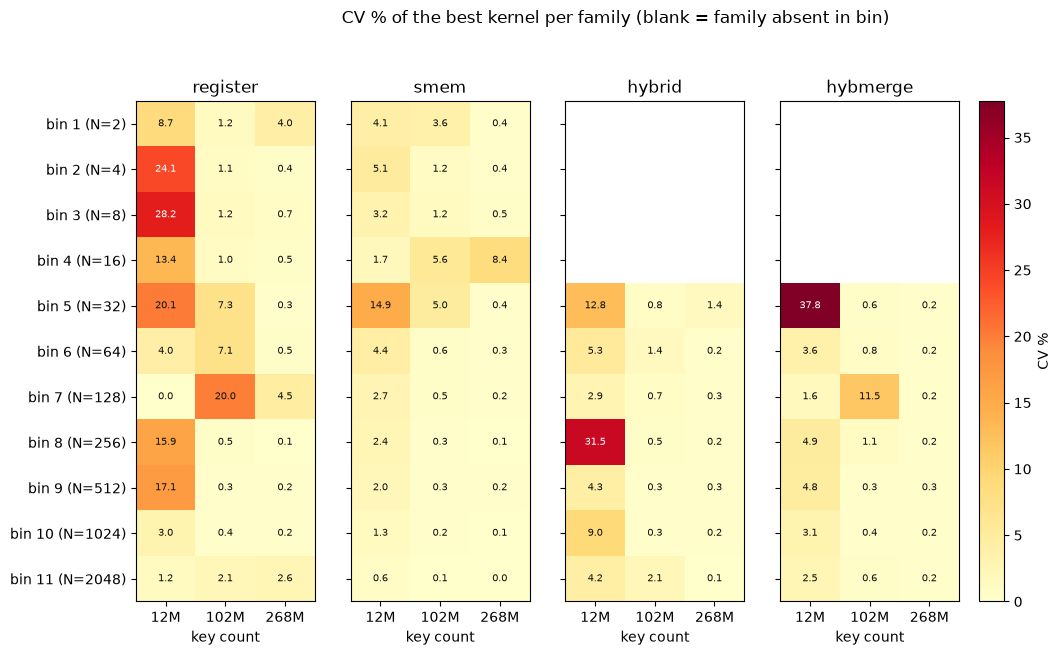

In [21]:
def plot_wall_vs_gpu(agg):
    g = agg[["kernel", "n_keys", "gpu_us", "wall_us"]]
    cmap = {nk: c for nk, c in zip(key_counts, ["#4269d0", "#e8834a", "#59a14f"])}

    fig, ax = plt.subplots(figsize=(7, 7))
    for nk in key_counts:
        s = g[g["n_keys"] == nk]
        ax.scatter(s["gpu_us"], s["wall_us"], s=18, alpha=0.6, color=cmap.get(nk, "#888"),
                   label=f"{nk // 10**6}M", edgecolor="white", linewidth=0.3)
    lo = min(g["gpu_us"].min(), g["wall_us"].min())
    hi = max(g["gpu_us"].max(), g["wall_us"].max())
    ax.plot([lo, hi], [lo, hi], color="#333", linewidth=1.0, linestyle="--", label="wall = gpu")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GPU-timestamp time (µs, median)")
    ax.set_ylabel("wall time (µs, median)")
    ax.set_title("Wall vs GPU time per experiment\n(gap above y=x = host dispatch overhead)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, title="key count")
    fig.tight_layout()
    return g.assign(overhead_us=g["wall_us"] - g["gpu_us"])


plot_wall_vs_gpu(agg)